# ForceGNN Usage Example

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.


In [1]:
# Import everything from the module
%load_ext autoreload
%autoreload 2

# Import everything from the module
import sys
sys.path.append('..')

import importlib
import torch
import torch.nn as nn

import torch_inference
importlib.reload(torch_inference)
from torch_inference import *
import functorch
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
clrs = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/Experimental"
plotsdir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/Plots/"



In [2]:
class ForceGNN(nn.Module):
    """
    Graph Neural Network for learning force decomposition.
    
    Forces are decomposed into:
    - F_env: Environmental/external forces (position-dependent, uses node_features[:, :2])
    - F_r: Pairwise interaction forces (distance-dependent)
    - Memory/drag term using Jacobian-vector product of F_env and tau_raw
    
    Node features: [x, y, vx, vy, type] - positions, velocities, and particle type
    """
    
    def __init__(self, hidden_dim=32, tau_init=1.0):
        super(ForceGNN, self).__init__()

        self.r_mean = 0.0
        self.r_std  = 1.0
        self.y_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.y_std  = np.array([1.0, 1.0], dtype=np.float32)
        self.x_mean = np.array([0.0, 0.0], dtype=np.float32)
        self.x_std  = float(1.0)

        self.interaction_net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),                          # SiLU == Swish
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )
        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 2)
        # )
        
        # self.interaction_net = nn.Sequential(
        #     nn.Linear(1, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 1)
        # )
        
        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 2)
        # )

        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim),
        #     nn.SiLU(),                          # SiLU == Swish
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, 2)
        # )
        # self.env_net = nn.Sequential(
        #     nn.Linear(2, hidden_dim),
        #     nn.SiLU(),                          # SiLU == Swish
        #     nn.LayerNorm(hidden_dim),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.LayerNorm(hidden_dim),
        #     nn.Linear(hidden_dim, hidden_dim),
        #     nn.SiLU(),
        #     nn.Linear(hidden_dim, 2)
        # )

        # self.interaction_net = nn.Sequential(
        #     nn.Linear(1, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        #     nn.Linear(hidden_dim, 1)
        # )

        # Learnable memory timescale
        self.tau_raw = nn.Parameter(
            torch.tensor(tau_init, dtype=torch.float32)
        )

    def _jvp(self, positions, velocities):
        """
        Compute Jacobian-vector product (∂F_env/∂x) · v using
        forward-mode AD via torch.func.jvp.
        
        Parameters:
        -----------
        positions  : (N, 2) position tensor
        velocities : (N, 2) velocity tensor (the tangent vector)
        
        Returns:
        --------
        Jv : (N, 2) JVP result
        """

        def f(pos):
            return self.env_net(pos)

        _, Jv = torch.func.jvp(f, (positions,), (velocities,))
        return Jv

    def forward(self, node_features, edge_indices, edge_features, return_components=False):
        """
        Forward pass of the model.
        
        Parameters:
        -----------
        node_features  : Tensor (N, 5) [x, y, vx, vy, type]
        edge_indices   : Tensor (2, E) edge connections
        edge_features  : Tensor (E, 3) [r, dx/r, dy/r]
        return_components : bool
            If True, return individual force components
        
        Returns:
        --------
        F_total or tuple of (F_total, F_r_aggregated, F_drag, F_env)
        """
        _y = getattr(self, "y_std", 1.0)
        y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
        if y_std == 0.0:
            y_std = 1.0
        
        _x = getattr(self, "x_std", 1.0)
        x_std = float(np.asarray(_x).flat[0]) if np.ndim(_x) != 0 else float(_x)
        if x_std == 0.0:
            x_std = 1.0

        # Extract positions and velocities
        positions  = node_features[:, :2]
        velocities = node_features[:, 2:4]

        # Environmental force
        #F_env = self.env_net(positions)

        # # Pairwise interaction force
        if edge_indices.shape[1] > 0:
            edge_distances  = edge_features[:, 0:1]
            F_r_scalar      = self.interaction_net(edge_distances)
            edge_unit_vectors = edge_features[:, 1:3]
            F_r_vector      = F_r_scalar*edge_unit_vectors

            target_indices  = edge_indices[1, :]
            N = node_features.shape[0]
            F_r_aggregated  = torch.zeros(N, 2, dtype=node_features.dtype, device=node_features.device)
            F_r_aggregated.scatter_add_(
                0,
                target_indices.long().unsqueeze(1).expand_as(F_r_vector),
                F_r_vector
            )
        else:
            F_r_aggregated = torch.zeros_like(positions)

        # (∂F_env/∂x)·v
        #Jv = self._jvp(positions, velocities)

        #Jv = self._jvp(positions, velocities)
        vel_term =  - (1.0/self.tau_raw)*velocities / y_std #self.tau_raw*Jv/ x_std 
        F_drag = vel_term * (2/3)

        # Total force
        F_total = F_drag  + F_r_aggregated # F_env + 

        if return_components:
            return F_total, F_drag, F_r_aggregated # F_env ,
        return F_total

In [3]:
def create_model(hidden_dim=32, tau_init=1.0):
    """
    Create a ForceGNN model.
    
    Parameters:
    -----------
    hidden_dim : int
        Hidden dimension for neural network layers
    
    Returns:
    --------
    ForceGNN
        Initialized model
    """
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)
    print(f"ForceGNN model created with hidden_dim={hidden_dim}")
    return model

In [4]:
def save_model(model, filepath, history=None):
    """
    Save a trained ForceGNN (PyTorch) model.

    Saves three files:
      <filepath>.pt          – model weights (state_dict)
      <filepath>_config.json – architecture hyperparameters needed to reconstruct the model
      <filepath>_norm.json   – normalisation statistics stored on the model
      <filepath>_history.json – training history (optional, if history is provided)

    Parameters
    ----------
    model : ForceGNN
        Trained model.
    filepath : str
        Base path (no extension). Extensions are added automatically.
    history : dict, optional
        Training history returned by train_model().
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    # --- weights ---
    torch.save(model.state_dict(), filepath)
    print(f"Model weights saved to: {filepath}")

    # --- architecture config ---
    # Infer hidden_dim from the first Linear layer of interaction_net
    hidden_dim = model.interaction_net[0].out_features
    tau_init   = float(model.tau_raw.detach().cpu())   # save current learned value as init hint
    config = {
        "hidden_dim": int(hidden_dim),
        "tau_init":   tau_init,
    }
    config_path = filepath.replace('.pt', '_config.json')
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)
    print(f"Model config saved to:  {config_path}")

    # --- normalisation stats ---
    def _to_list(v):
        if isinstance(v, np.ndarray):
            return v.tolist()
        return float(v)

    norm = {
        "r_mean": _to_list(getattr(model, "r_mean", 0.0)),
        "r_std":  _to_list(getattr(model, "r_std",  1.0)),
        "y_mean": _to_list(getattr(model, "y_mean", np.array([0.0, 0.0]))),
        "y_std":  _to_list(getattr(model, "y_std",  np.array([1.0, 1.0]))),  # was scalar default
        "x_mean": _to_list(getattr(model, "x_mean", np.array([0.0, 0.0]))),
        "x_std":  _to_list(getattr(model, "x_std",  1.0)),
    }
    norm_path = filepath.replace('.pt', '_norm.json')
    with open(norm_path, 'w') as f:
        json.dump(norm, f, indent=2)
    print(f"Normalisation stats saved to: {norm_path}")

    # --- history ---
    if history is not None:
        history_path = filepath.replace('.pt', '_history.json')
        # Convert any numpy/torch scalars to plain Python floats for JSON
        clean = {}
        for k, v in history.items():
            if isinstance(v, (list, tuple)):
                clean[k] = [float(x) if not isinstance(x, str) else x for x in v]
            else:
                clean[k] = float(v) if not isinstance(v, str) else v
        with open(history_path, 'w') as f:
            json.dump(clean, f, indent=2)
        print(f"History saved to: {history_path}")

def load_history(filepath):
    """
    Load training history saved by save_model().

    Parameters
    ----------
    filepath : str
        Base path used when saving (with or without .pt extension).

    Returns
    -------
    dict or None
        Training history dict, or None if no history file exists.
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    history_path = filepath.replace('.pt', '_history.json')

    try:
        with open(history_path, 'r') as f:
            history = json.load(f)
        print(f"History loaded from: {history_path}")
        return history
    except FileNotFoundError:
        print(f"No history file found at: {history_path}")
        return None
    
def load_model(filepath, hidden_dim=None, tau_init=1.0, device=None):
    """
    Load a saved ForceGNN (PyTorch) model.

    Looks for:
      <filepath>.pt           – weights
      <filepath>_config.json  – architecture config (optional if hidden_dim is passed)
      <filepath>_norm.json    – normalisation stats (optional)

    Parameters
    ----------
    filepath : str
        Path to the .pt weights file (with or without the .pt extension).
    hidden_dim : int, optional
        Hidden dimension used when the model was created. If None, reads from
        the saved config file. Required if no config file exists.
    tau_init : float, optional
        Only used as a fallback if no config file is found.
    device : torch.device or str, optional
        Device to load weights onto. Defaults to CPU.

    Returns
    -------
    ForceGNN
        Loaded model in eval() mode.
    """
    if not filepath.endswith('.pt'):
        filepath = filepath + '.pt'

    if device is None:
        device = torch.device('cpu')

    # --- architecture config ---
    config_path = filepath.replace('.pt', '_config.json')
    try:
        with open(config_path, 'r') as f:
            config = json.load(f)
        hidden_dim = hidden_dim or config["hidden_dim"]
        tau_init   = config.get("tau_init", tau_init)
        print(f"Loaded config from: {config_path}")
    except FileNotFoundError:
        if hidden_dim is None:
            raise ValueError(
                f"No config file found at {config_path} and hidden_dim not provided. "
                "Pass hidden_dim explicitly."
            )
        print(f"No config file found; using hidden_dim={hidden_dim}, tau_init={tau_init}")

    # --- reconstruct model ---
    model = ForceGNN(hidden_dim=hidden_dim, tau_init=tau_init)

    # --- load weights ---
    state_dict = torch.load(filepath, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Weights loaded from: {filepath}")

    # --- normalisation stats ---
    norm_path = filepath.replace('.pt', '_norm.json')
    try:
        with open(norm_path, 'r') as f:
            norm = json.load(f)
        model.r_mean = float(norm.get("r_mean", 0.0))
        model.r_std  = float(norm.get("r_std",  1.0)) or 1.0
        model.y_mean = np.array(norm.get("y_mean", [0.0, 0.0]), dtype=np.float32)
        model.y_std = norm.get("y_std", 1.0)
        if isinstance(model.y_std, list):
            model.y_std = np.array(model.y_std, dtype=np.float32)
        else:
            model.y_std = float(model.y_std) or 1.0
        #model.y_std  = float(norm.get("y_std",  1.0)) or 1.0
        model.x_mean = np.array(norm.get("x_mean", [0.0, 0.0]), dtype=np.float32)
        model.x_std  = float(norm.get("x_std",  1.0)) or 1.0
        print(f"Normalisation restored: r_mean={model.r_mean:.6g}, r_std={model.r_std:.6g}")
    except FileNotFoundError:
        print(f"No normalisation file at {norm_path}; using defaults.")

    model.to(device)
    model.eval()
    print(f"  hidden_dim={hidden_dim}, tau={float(model.tau_raw.detach()):.6f}")
    return model

In [5]:
def evaluate_model(model, test_data, verbose=True):
    test_predictions_masked = []
    test_targets_masked = []
    index_map = []  # (frame_idx, node_idx) for each masked row

    total_nodes = 0
    masked_nodes = 0

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            predictions = model(
                torch.tensor(data_point['nodes']),
                torch.tensor(data_point['edges']),
                torch.tensor(data_point['edge_feat'])
            ).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            mask_indices = mask == 1.0
            #mask_indices = mask.astype(bool)

            masked_pred = predictions[mask_indices]
            masked_targ = targets[mask_indices]

            test_predictions_masked.append(masked_pred)
            test_targets_masked.append(masked_targ)

            # record original indices
            node_ids = np.where(mask_indices)[0]
            index_map.extend([(frame_idx, int(n)) for n in node_ids])

            total_nodes  += len(predictions)
            masked_nodes += int(np.sum(mask_indices))

    if len(test_predictions_masked) > 0:
        test_predictions_flat = np.vstack(test_predictions_masked)
        test_targets_flat     = np.vstack(test_targets_masked)
        num_masked_nodes      = len(test_predictions_flat)

        if num_masked_nodes > 0:
            squared_errors = (test_predictions_flat - test_targets_flat) ** 2
            test_mse_x = np.mean(squared_errors[:, 0])
            test_mse_y = np.mean(squared_errors[:, 1])
            test_mse   = np.mean(squared_errors)
            test_mae   = np.mean(np.abs(test_predictions_flat - test_targets_flat))
        else:
            test_mse_x = test_mse_y = test_mse = test_mae = 0.0
    else:
        test_predictions_flat = np.zeros((0, 2), dtype=np.float32)
        test_targets_flat     = np.zeros((0, 2), dtype=np.float32)
        index_map        = []
        num_masked_nodes = 0
        test_mse_x = test_mse_y = test_mse = test_mae = 0.0

    if verbose:
        print(f"\nTest Set Evaluation (masked nodes only):")
        print(f"  Total nodes in test set: {total_nodes}")
        print(f"  Masked nodes (mask=1): {masked_nodes} ({100*masked_nodes/total_nodes:.1f}%)")
        print(f"  MSE (x-direction): {test_mse_x:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (y-direction): {test_mse_y:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MSE (overall): {test_mse:.6f} (on {num_masked_nodes:.0f} masked nodes)")
        print(f"  MAE: {test_mae:.6f} (on {num_masked_nodes:.0f} masked nodes)")

    return {
        'mse':              test_mse,
        'mse_x':            test_mse_x,
        'mse_y':            test_mse_y,
        'mae':              test_mae,
        'predictions':      test_predictions_flat,
        'targets':          test_targets_flat,
        'index_map':        index_map,
        'num_masked_nodes': num_masked_nodes,
        'total_nodes':      total_nodes,
    }

In [6]:
def estimate_noise_magnitude(model, test_data):
    all_residuals = []
    all_masks = []

    model.eval()
    with torch.no_grad():
        for data_point in test_data:
            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            Y_pred = model(node_features, edge_indices, edge_features).cpu().numpy()  # (N, 2)

            Y_true = data_point['targets']
            if isinstance(Y_true, torch.Tensor):
                Y_true = Y_true.cpu().numpy()

            resid = Y_true - Y_pred  # (N, 2)
            all_residuals.append(resid)

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
                all_masks.append(mask)
            else:
                all_masks.append(np.ones(len(resid), dtype=np.float32))

    all_residuals = np.vstack(all_residuals)
    all_masks     = np.concatenate(all_masks)

    mask_indices     = all_masks == 1.0
    masked_residuals = all_residuals[mask_indices]

    if len(masked_residuals) == 0:
        print("Warning: No masked nodes found in test data for noise estimation")
        return {
            "per_dim_var":  np.array([0.0, 0.0]),
            "per_dim_std":  np.array([0.0, 0.0]),
            "overall_rms":  0.0,
            "num_samples":  0,
            "num_frames":   len(test_data),
            "mean_residual": np.array([0.0, 0.0]),
        }

    num_samples = len(masked_residuals)
    mean_r      = np.mean(masked_residuals, axis=0)
    var_r       = np.sum((masked_residuals - mean_r)**2, axis=0) / (num_samples - 1) if num_samples > 1 else np.zeros(2)
    std_r       = np.sqrt(var_r)
    overall_rms = np.sqrt(np.mean(np.sum(masked_residuals**2, axis=1)))

    return {
        "per_dim_var":        var_r,
        "per_dim_std":        std_r,
        "overall_rms":        float(overall_rms),
        "num_samples":        num_samples,
        "num_frames":         len(test_data),
        "mean_residual":      mean_r,
        "sum_residuals_sq_x": np.sum(masked_residuals[:, 0]**2),
        "sum_residuals_sq_y": np.sum(masked_residuals[:, 1]**2),
    }

def evaluate_model_frames(model, test_data, verbose=True):
    rows = []

    model.eval()
    with torch.no_grad():
        for frame_idx, data_point in enumerate(test_data):
            frame_id = data_point.get('frame', frame_idx)

            node_features = torch.tensor(data_point['nodes'],     dtype=torch.float32)
            edge_indices  = torch.tensor(data_point['edges'],     dtype=torch.long)
            edge_features = torch.tensor(data_point['edge_feat'], dtype=torch.float32)

            predictions = model(node_features, edge_indices, edge_features).cpu().numpy()

            targets = data_point['targets']
            if isinstance(targets, torch.Tensor):
                targets = targets.cpu().numpy()

            nodes = data_point['nodes']

            if 'mask' in data_point:
                mask = data_point['mask']
                if isinstance(mask, torch.Tensor):
                    mask = mask.cpu().numpy()
            else:
                mask = np.ones(len(predictions), dtype=np.float32)

            if 'particle_ids' in data_point:
                node_ids = data_point['particle_ids']
            else:
                node_ids = np.arange(len(predictions))

            mask_indices = mask == 1.0

            theta_pred   = np.arctan2(predictions[:, 1], predictions[:, 0])
            theta_true   = np.arctan2(targets[:, 1],     targets[:, 0])
            errors_theta = np.abs(theta_pred - theta_true)
            errors_x     = predictions[:, 0] - targets[:, 0]
            errors_y     = predictions[:, 1] - targets[:, 1]
            errors       = np.sqrt(errors_x**2 + errors_y**2)

            num_neighbors_arr = data_point['num_neighbors']
            nn_r_arr          = data_point['nn_r']

            for i in range(len(predictions)):
                if mask_indices[i]:
                    rows.append({
                        'frame':         frame_id,
                        'node_id':       int(node_ids[i]) if hasattr(node_ids[i], '__int__') else node_ids[i],
                        'x':             float(nodes[i, 0]),
                        'y':             float(nodes[i, 1]),
                        'vx':            float(nodes[i, 2]),
                        'vy':            float(nodes[i, 3]),
                        'num_neighbors': float(num_neighbors_arr[i]),
                        'nn_r':          float(nn_r_arr[i]),
                        'error':         float(errors[i]),
                        'error_theta':   float(errors_theta[i]),
                        'error_x':       float(errors_x[i]),
                        'error_y':       float(errors_y[i]),
                        'pred_x':        float(predictions[i, 0]),
                        'pred_y':        float(predictions[i, 1]),
                        'target_x':      float(targets[i, 0]),
                        'target_y':      float(targets[i, 1]),
                    })

    df = pd.DataFrame(rows)

    if verbose:
        if len(df) > 0:
            print(f"\nFrame-based Evaluation:")
            print(f"  Total rows:     {len(df)}")
            print(f"  Unique frames:  {df['frame'].nunique()}")
            print(f"  Unique nodes:   {df['node_id'].nunique()}")
            print(f"  Mean error:     {df['error'].mean():.6f}")
            print(f"  Median error:   {df['error'].median():.6f}")
            print(f"  Std error:      {df['error'].std():.6f}")
        else:
            print("\nFrame-based Evaluation: No data (all nodes may have been masked out)")

    return df

In [7]:
def get_force_at_distance(model, r):
    """
    Get the learned pairwise force magnitude at a given distance.
    
    Parameters:
    -----------
    model : ForceGNN
        Trained model
    r : float
        Distance value
    
    Returns:
    --------
    float
        Force magnitude F_r(r)
    """

    model.eval()
    r_mean = float(getattr(model, "r_mean", 0.0))
    r_std  = float(getattr(model, "r_std", 1.0))
    if r_std == 0.0:
        r_std = 1.0
    _y = getattr(model, "y_std", 1.0)
    y_std = float(np.asarray(_y).flat[0]) if np.ndim(_y) != 0 else float(_y)
    if y_std == 0.0:
        y_std = 1.0
    #print(r_std)
    r_norm = (r) / r_std #- r_mean
    
    F_norm = model.interaction_net(torch.tensor([[r_norm]], dtype=torch.float32)).item()
    with torch.no_grad():
        return y_std * F_norm

def get_tau(model):
    return float(model.tau_raw.detach().numpy())

In [ ]:
# parameters
datatype = "STEM" # "EMT" or "Peptide" or "MDCK"
dataset_names = ["MESE","STEM"]
seeds = [1,2] #[1,2]

r_cut = 100 #sensible cutoff value for pairwise forces
Dynamics = "OD_Persistent" # "UD" or "OD_Persistent"
Derivative = "Naive" # "Naive" or "Weak"
datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/Data_CSVs/Experimental"
#training parameters
hiddenDs = 64
Epochs = 200
#save model
datasave = '//Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/'
save_path = Path("/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/dataIN/")  # or your scratch dir

print("Loading source code...")

print("Loading data...")
for dd in dataset_names:
    for seed in seeds:
        datatype = dd
        # ------------  Load data ---------------#
        if datatype == "MESE":
            nameSave_DataIN =  "dataIn_"+datatype+"_"+Derivative+"_Rcut"+str(r_cut)+"_seed"+str(seed)+"_Last140.pkl"
        elif datatype == "STEM":
            nameSave_DataIN = "dataIn_"+datatype+"_"+Derivative+"_Rcut"+str(r_cut)+"_seed"+str(seed)+"_First140.pkl"


        with open(save_path / nameSave_DataIN, "rb") as f:
            data_loaded = pickle.load(f)

        # model parameters
        # Train model
        Epochs = 200
        far_field_strength = 1000.0
        far_field_r = 100.0
        max_r = 120.0
        K_far = 1000
        tau_mem0=10
        Environmental=False
        if Environmental:
            nameSave = "model_TauInit"+str(tau_mem0)+"_"+datatype+"_"+Dynamics+"_"+Derivative+"_HD"+str(hiddenDs)+"_"+str(Epochs)+"_Rcut"+str(r_cut)+"_FF"+str(far_field_strength)+"_"+str(far_field_r)+"_"+str(max_r)
        else:
            nameSave = "modelFenvPytorch_TauInit"+str(tau_mem0)+"_"+datatype+str(seed)+"_Rcut"+str(r_cut)+"_FarFieldR100_"+str(Epochs)+"Epochs_NoFenv_"+Derivative
       
        loaded_model = load_model(datasave+nameSave, hidden_dim=64)

        loaded_model_history = load_history(datasave+nameSave)
        dataset = data_loaded["dataset"]
        meta = data_loaded["meta"]
        train_frac = 0.7
        val_frac = 0.3
        test_frac = 0.0
        train_data, val_data, test_data, all_data = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac,randomize = False)
        evaluation = evaluate_model(loaded_model,val_data,verbose = False)

        predictions = evaluation['predictions']
        targets = evaluation['targets']
        rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
        rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)



        if datatype == "MESE" and seed == 1:
            dataset_MS_1 = dataset
            model_MS_1 = loaded_model
            model_history_MS_1 = loaded_model_history
            Rsq_MS1model_MS_1 = (rsq_ax+rsq_ay)/2
        elif datatype == "MESE" and seed == 2:
            dataset_MS_2 = dataset
            model_MS_2 = loaded_model
            model_history_MS_2 = loaded_model_history
            Rsq_MS2model_MS_2 = (rsq_ax+rsq_ay)/2
        elif datatype == "STEM" and seed == 1:
            dataset_STEM_1 = dataset
            model_STEM_1 = loaded_model
            model_history_STEM_1 = loaded_model_history
            Rsq_STEM1model_STEM_1 = (rsq_ax+rsq_ay)/2
        elif datatype == "STEM" and seed == 2:
            dataset_STEM_2 = dataset
            model_STEM_2 = loaded_model
            model_history_STEM_2 = loaded_model_history
            Rsq_STEM2model_STEM_2 = (rsq_ax+rsq_ay)/2


Loading source code...
Loading data...
Loaded config from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive_config.json
Weights loaded from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive.pt
Normalisation restored: r_mean=66.3496, r_std=23.279
  hidden_dim=64, tau=0.191900
History loaded from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE1_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive_history.json
Data splits:
  Train: 98
  Val:   42
  Test:  0
Loaded config from: //Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/CellStatTransitionPytorch/models/modelFenvPytorch_TauInit10_MESE2_Rcut100_FarFieldR100_200Epochs_NoFenv_Naive_config.json
Weights loaded from: //Users/billiemeado

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


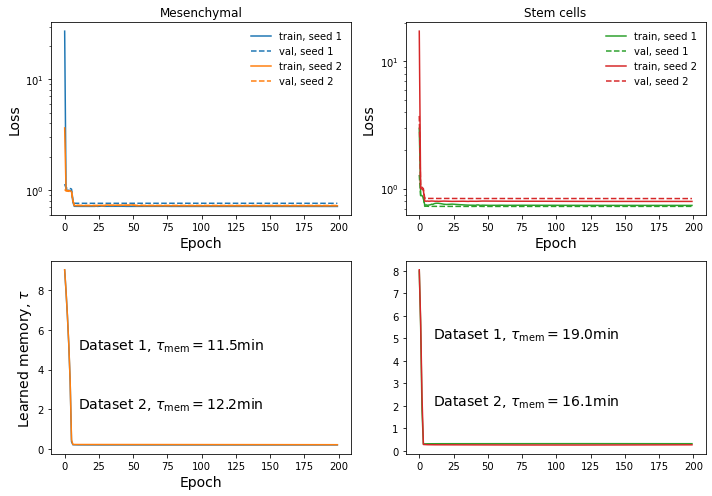

In [12]:
fig,ax = plt.subplots(2,2,figsize = (10,7))
ax[0,0].plot(model_history_MS_1['train_loss'],color = clrs[0],linestyle = '-',label = 'train, seed 1')
ax[0,0].plot(model_history_MS_1['val_loss'],color = clrs[0],linestyle = '--',label = 'val, seed 1')
ax[0,0].plot(model_history_MS_2['train_loss'],color = clrs[1],linestyle = '-',label = 'train, seed 2')
ax[0,0].plot(model_history_MS_2['val_loss'],color = clrs[1],linestyle = '--',label = 'val, seed 2')
ax[0,1].plot(model_history_STEM_1['train_loss'],color = clrs[2],linestyle = '-',label = 'train, seed 1')
ax[0,1].plot(model_history_STEM_1['val_loss'],color = clrs[2],linestyle = '--',label = 'val, seed 1')
ax[0,1].plot(model_history_STEM_2['train_loss'],color = clrs[3],linestyle = '-',label = 'train, seed 2')
ax[0,1].plot(model_history_STEM_2['val_loss'],color = clrs[3],linestyle = '--',label = 'val, seed 2')

ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('Epoch',fontsize = 14)
ax[0,0].set_ylabel('Loss',fontsize = 14)
ax[0,0].set_title("Mesenchymal")

ax[0,1].set_yscale('log')
ax[0,1].set_xlabel('Epoch',fontsize = 14)
ax[0,1].set_ylabel('Loss',fontsize = 14)
ax[0,1].set_title("Stem cells")
ax[0,0].legend(frameon = False)
ax[0,1].legend(frameon = False)
text1 = r"Dataset 1, $\tau_{\mathrm{mem}} = $"+str(np.round(model_history_MS_1['tau_raw'][-1]*60,1))+"min"
text2 = r"Dataset 2, $\tau_{\mathrm{mem}} = $"+str(np.round(model_history_MS_2['tau_raw'][-1]*60,1))+"min"
text3 = r"Dataset 1, $\tau_{\mathrm{mem}} = $"+str(np.round(model_history_STEM_1['tau_raw'][-1]*60,1))+"min"
text4 = r"Dataset 2, $\tau_{\mathrm{mem}} = $"+str(np.round(model_history_STEM_2['tau_raw'][-1]*60,1))+"min"
ax[1,0].plot(model_history_MS_1['tau_raw'],color = clrs[0],linestyle = '-')
ax[1,0].plot(model_history_MS_2['tau_raw'],color = clrs[1],linestyle = '-')
ax[1,1].plot(model_history_STEM_1['tau_raw'],color = clrs[2],linestyle = '-')
ax[1,0].text(10,5,text1,fontsize = 14)
ax[1,0].text(10,2,text2,fontsize = 14)
ax[1,1].text(10,5,text3,fontsize = 14)
ax[1,1].text(10,2,text4,fontsize = 14)
ax[1,1].plot(model_history_STEM_2['tau_raw'],color = clrs[3],linestyle = '-')
ax[1,0].legend(frameon = False)
ax[1,0].set_xlabel('Epoch',fontsize = 14)
ax[1,0].set_ylabel(r'Learned memory, $\tau$',fontsize = 14)

fig.tight_layout()


In [13]:
Rsquares = np.zeros((len(dataset_names),len(seeds),2))
datasets = [[dataset_MS_1,dataset_MS_2],[dataset_STEM_1,dataset_STEM_2]]
loaded_models = [[model_MS_1,model_MS_2],[model_STEM_1,model_STEM_2]]
dataset_labels = [["Mese 1","Mese 2"],["Stem 1","Stem 2"]]
NoiseMagnitudes = np.zeros((len(dataset_names),len(seeds),2))
for dd,dataset in enumerate(dataset_names):
    for s,seed in enumerate(seeds):
        #for i in range(2):
        dataset = datasets[dd][s]
        print("Dataset",dd,seed,s,"data",dataset_labels[dd][s])
        train_data, val_data, test_data, all_data = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac,randomize = False)

        evaluation = evaluate_model(loaded_models[dd][s],val_data,verbose = False)


        predictions = evaluation['predictions']
        targets = evaluation['targets']
        Overall_noise = estimate_noise_magnitude(loaded_models[dd][s], val_data)
        NoiseMagnitudes[dd,s,0] = Overall_noise['per_dim_std'][0]
        NoiseMagnitudes[dd,s,1] = Overall_noise['per_dim_std'][1]

        predictions = evaluation['predictions']
        targets = evaluation['targets']
        rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
        rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
        Rsquares[dd,s,0] = (rsq_ax+rsq_ay)/2
        #Rsquares[dd,s,1] = rsq_ay


Dataset 0 1 0 data Mese 1
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 0 2 1 data Mese 2
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 1 1 0 data Stem 1
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 1 2 1 data Stem 2
Data splits:
  Train: 98
  Val:   42
  Test:  0


In [14]:
Rsquares_seeds = np.zeros((len(dataset_names),len(seeds),2))
datasets = [[dataset_MS_1,dataset_MS_2],[dataset_STEM_1,dataset_STEM_2]]
loaded_models = [[model_MS_1,model_MS_2],[model_STEM_1,model_STEM_2]]
dataset_labels = [["Mese 1","Mese 2"],["Stem 1","Stem 2"]]
NoiseMagnitudes = np.zeros((len(dataset_names),len(seeds),2))
for dd,dataset in enumerate(dataset_names):
    for s,seed in enumerate(seeds):
        #for i in range(2):
        if s==0:
            ss=1
        elif s==1:
            ss=0
        dataset = datasets[dd][ss]
        print("Dataset",dd,seed,s,"data",dataset_labels[dd][s])
        train_data, val_data, test_data, all_data = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac,randomize = False)

        evaluation = evaluate_model(loaded_models[dd][s],train_data,verbose = False)


        predictions = evaluation['predictions']
        targets = evaluation['targets']
        Overall_noise = estimate_noise_magnitude(loaded_models[dd][s], train_data)
        NoiseMagnitudes[dd,s,0] = Overall_noise['per_dim_std'][0]
        NoiseMagnitudes[dd,s,1] = Overall_noise['per_dim_std'][1]

        predictions = evaluation['predictions']
        targets = evaluation['targets']
        rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
        rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
        Rsquares_seeds[dd,s,0] = (rsq_ax+rsq_ay)/2

Dataset 0 1 0 data Mese 1
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 0 2 1 data Mese 2
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 1 1 0 data Stem 1
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 1 2 1 data Stem 2
Data splits:
  Train: 98
  Val:   42
  Test:  0


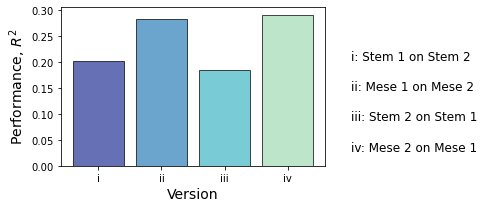

In [15]:
labels= [r"Stem 1 on Stem 2",r"Mese 1 on Mese 2",r"Stem 2 on Stem 1",r"Mese 2 on Mese 1"]
versions = ["i","ii","iii","iv"]
clrs = ['#253494','#2c7fb8','#41b6c4','#a1dab4','#ffffcc','purple']
R_squared_seeds = [Rsquares_seeds[1,0,0],Rsquares_seeds[0,0,0],Rsquares_seeds[1,1,0],Rsquares_seeds[0,1,0]] #Rsq_PI2model_PI_2,Rsq_PI1model_PI_2,Rsq_PI2model_PI_1]

fig,ax = plt.subplots(figsize = (7,3))
ax.bar(versions,R_squared_seeds,color = clrs,edgecolor = 'black',alpha = 0.7)

ax.set_xlabel('Version',fontsize = 14)
ax.set_ylabel(r'Performance, $R^2$',fontsize = 14)
text1 = versions[0] +': '+labels[0]+'\n'
text2 = versions[1] +': '+labels[1]+'\n'
text3 = versions[2] +': '+labels[2]+'\n'
text4 = versions[3] +': '+labels[3]+'\n'

ax.text(len(versions),0.6*np.max(R_squared_seeds),text1,fontsize = 12)
ax.text(len(versions),0.4*np.max(R_squared_seeds),text2,fontsize = 12)
ax.text(len(versions),0.2*np.max(R_squared_seeds),text3,fontsize = 12)
ax.text(len(versions),0.0*np.max(R_squared_seeds),text4,fontsize = 12)


#ax.set_ylim(0,np.max(R_squared)*1.1)
fig.tight_layout()

In [16]:
Rsquares_cross = np.zeros((len(dataset_names),len(seeds),2))
datasets = [[dataset_MS_1,dataset_MS_2],[dataset_STEM_1,dataset_STEM_2]]
loaded_models = [[model_MS_1,model_MS_2],[model_STEM_1,model_STEM_2]]
dataset_labels = [["Mese 1","Mese 2"],["Stem 1","Stem 2"]]
NoiseMagnitudes = np.zeros((len(dataset_names),len(seeds),2))
for dd,dataset in enumerate(dataset_names):
    for s,seed in enumerate(seeds):
        #for i in range(2):
        if dd==0:
            d=1
        elif dd==1:
            d=0
        dataset = datasets[d][s]
        print("Dataset",dd,seed,s,"data",dataset_labels[dd][s])
        train_data, val_data, test_data, all_data = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac,randomize = False)

        evaluation = evaluate_model(loaded_models[dd][s],val_data,verbose = False)


        predictions = evaluation['predictions']
        targets = evaluation['targets']
        Overall_noise = estimate_noise_magnitude(loaded_models[dd][s], val_data)
        NoiseMagnitudes[dd,s,0] = Overall_noise['per_dim_std'][0]
        NoiseMagnitudes[dd,s,1] = Overall_noise['per_dim_std'][1]

        predictions = evaluation['predictions']
        targets = evaluation['targets']
        rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
        rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
        Rsquares_cross[dd,s,0] = (rsq_ax+rsq_ay)/2

Dataset 0 1 0 data Mese 1
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 0 2 1 data Mese 2
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 1 1 0 data Stem 1
Data splits:
  Train: 98
  Val:   42
  Test:  0
Dataset 1 2 1 data Stem 2
Data splits:
  Train: 98
  Val:   42
  Test:  0


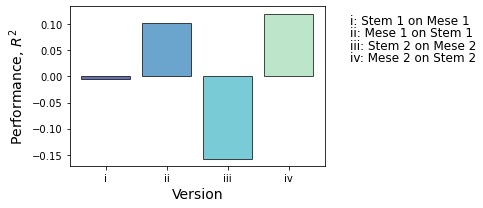

In [17]:
labels= [r"Stem 1 on Mese 1",r"Mese 1 on Stem 1",r"Stem 2 on Mese 2",r"Mese 2 on Stem 2"]
versions = ["i","ii","iii","iv"]
clrs = ['#253494','#2c7fb8','#41b6c4','#a1dab4','#ffffcc','purple']
R_squared_cross = [Rsquares_cross[1,0,0],Rsquares_cross[0,0,0],Rsquares_cross[1,1,0],Rsquares_cross[0,1,0]] #Rsq_PI2model_PI_2,Rsq_PI1model_PI_2,Rsq_PI2model_PI_1]

fig,ax = plt.subplots(figsize = (7,3))
ax.bar(versions,R_squared_cross,color = clrs,edgecolor = 'black',alpha = 0.7)

ax.set_xlabel('Version',fontsize = 14)
ax.set_ylabel(r'Performance, $R^2$',fontsize = 14)
text1 = versions[0] +': '+labels[0]+'\n'
text2 = versions[1] +': '+labels[1]+'\n'
text3 = versions[2] +': '+labels[2]+'\n'
text4 = versions[3] +': '+labels[3]+'\n'

ax.text(len(versions),0.6*np.max(R_squared_cross),text1,fontsize = 12)
ax.text(len(versions),0.4*np.max(R_squared_cross),text2,fontsize = 12)
ax.text(len(versions),0.2*np.max(R_squared_cross),text3,fontsize = 12)
ax.text(len(versions),0.0*np.max(R_squared_cross),text4,fontsize = 12)

#ax.set_ylim(0,np.max(R_squared)*1.1)
fig.tight_layout()


/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_2725/3133802209.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.plot(labels[:2],np.add(Noise_x[:2],Noise_y[:2]),'o',color = 'tab:blue',marker = 'v',linestyle = '',markersize = 10)
/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_2725/3133802209.py:34: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax2.plot(labels[2:],np.add(Noise_x[2:],Noise_y[2:]),'o',color = 'tab:purple',marker = 'v',linestyle = '',markersize = 10)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/wt/4tgp65891vd4l6wskkxdnvk40000gn/T/ipykernel_2725/3133802209.py:46: UserWarning: marker is redundantl

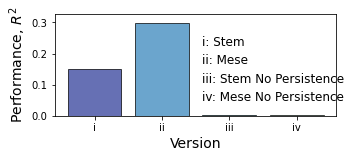

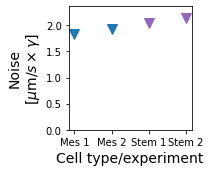

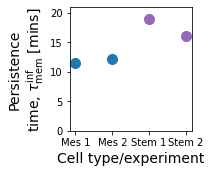

In [18]:
labels= [r"Stem 1 on Stem 1",r"Mese 1 on Mese 1",r"Stem 2 on Stem 2",r"Mese 2 on Mese 2"]
versions = ["i","ii","iii","iv"]
labels= [r"Stem",r"Mese",r"Stem No Persistence",r"Mese No Persistence"]

clrs = ['#253494','#2c7fb8','#41b6c4','#a1dab4','#ffffcc','purple']
R_squared = [Rsquares[1,0,0],Rsquares[0,0,0],Rsquares[1,1,0],Rsquares[0,1,0]] #Rsq_PI2model_PI_2,Rsq_PI1model_PI_2,Rsq_PI2model_PI_1]
R_squared = [Rsquares[1,0,0],Rsquares[0,0,0],0.0017,0.0025] #Rsq_PI2model_PI_2,Rsq_PI1model_PI_2,Rsq_PI2model_PI_1]

fig,ax = plt.subplots(figsize = (5,2.2))
ax.bar(versions,R_squared,color = clrs,edgecolor = 'black',alpha = 0.7)

ax.set_xlabel('Version',fontsize = 14)
ax.set_ylabel(r'Performance, $R^2$',fontsize = 14)
text1 = versions[0] +': '+labels[0]+'\n'
text2 = versions[1] +': '+labels[1]+'\n'
text3 = versions[2] +': '+labels[2]+'\n'
text4 = versions[3] +': '+labels[3]+'\n'

ax.text(len(versions)*0.4,0.6*np.max(R_squared),text1,fontsize = 12)
ax.text(len(versions)*0.4,0.4*np.max(R_squared),text2,fontsize = 12)
ax.text(len(versions)*0.4,0.2*np.max(R_squared),text3,fontsize = 12)
ax.text(len(versions)*0.4,0.0*np.max(R_squared),text4,fontsize = 12)


ax.set_ylim(0,np.max(R_squared)*1.1)
fig.tight_layout()
fig.savefig(plotsdir+"R2Comp.pdf")

labels = ['Mes 1','Mes 2','Stem 1','Stem 2']
fig2,ax2 = plt.subplots(figsize = (3,2.5))
Noise_x = [NoiseMagnitudes[0,0,0],NoiseMagnitudes[0,1,0],NoiseMagnitudes[1,0,0],NoiseMagnitudes[1,1,0]]
Noise_y = [NoiseMagnitudes[0,0,1],NoiseMagnitudes[0,1,1],NoiseMagnitudes[1,0,1],NoiseMagnitudes[1,1,1]]
ax2.plot(labels[:2],np.add(Noise_x[:2],Noise_y[:2]),'o',color = 'tab:blue',marker = 'v',linestyle = '',markersize = 10)
ax2.plot(labels[2:],np.add(Noise_x[2:],Noise_y[2:]),'o',color = 'tab:purple',marker = 'v',linestyle = '',markersize = 10)
ax2.legend(frameon = False)
ax2.set_xlabel(r'Cell type/experiment',fontsize = 14)
ax2.set_ylabel('Noise\n'+ r'[$\mu$m$/s \times \gamma$]',fontsize = 14)

ax2.set_ylim(0,1.1*np.max(np.add(Noise_x,Noise_y)))
fig2.tight_layout()
fig2.savefig(plotsdir+"NoiseComp.pdf")


fig2,ax2 = plt.subplots(figsize =  (3,2.5))
Timescales= [get_tau(model_MS_1),get_tau(model_MS_2),get_tau(model_STEM_1),get_tau(model_STEM_2)]
ax2.plot(labels[:2],np.multiply(Timescales[:2],60),'o',color ='tab:blue',marker = 'o',linestyle = '',markersize = 10)
ax2.plot(labels[2:],np.multiply(Timescales[2:],60),'o',color ='tab:purple',marker = 'o',linestyle = '',markersize = 10)
ax2.legend(frameon = False)
ax2.set_xlabel(r'Cell type/experiment',fontsize = 14)
ax2.set_ylabel('Persistence\n'+r'time, $\tau^{\mathrm{inf}}_{\mathrm{mem}}$ [mins]',fontsize = 14)
fig2.tight_layout()
ax2.set_ylim(0,1.1*60*np.max(Timescales))
fig2.savefig(plotsdir+"MemoryComp.pdf")



In [19]:
#max_dist = 1
r_cut = 120 # 120

r_arr = np.linspace(5,r_cut,100)
force_infer_Mese_1 = []
force_infer_Mese_2 = []
force_infer_Stem_1= []
force_infer_Stem_2= []

for datatype in dataset_names:
    for seed in seeds:
        for r in r_arr:
            if datatype == "MESE" and seed == 1:
                force_infer_Mese_1.append(get_force_at_distance(model_MS_1, r)) #
            elif datatype == "MESE" and seed == 2:
                force_infer_Mese_2.append(get_force_at_distance(model_MS_2, r)) #
            elif datatype == "STEM" and seed == 1:
                force_infer_Stem_1.append(get_force_at_distance(model_STEM_1, r)) #
            elif datatype == "STEM" and seed == 2:
                force_infer_Stem_2.append(get_force_at_distance(model_STEM_2, r)) #
                #force_infer_PI_2.append(get_force_at_distance(loaded_model_PI_2, r)) #

r_arr_plot = np.multiply(r_arr,1)

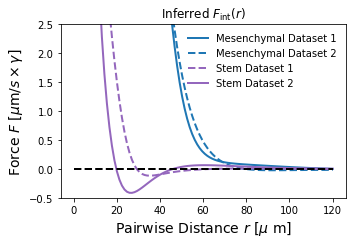

In [20]:
# Plot training history
fig,ax  = plt.subplots(1,figsize = (5,3.5))
Factor = 1
ax.plot(r_arr_plot,force_infer_Mese_1,color = 'tab:blue',linestyle = '-',linewidth = 2,label = 'Mesenchymal Dataset 1')
ax.plot(r_arr_plot,force_infer_Mese_2,color = 'tab:blue',linestyle = '--',linewidth = 2,label = 'Mesenchymal Dataset 2')
ax.plot(r_arr_plot,np.multiply(force_infer_Stem_1,Factor),color = 'tab:purple',linestyle = '--',linewidth = 2,label = 'Stem Dataset 1') # (no induction)')
ax.plot(r_arr_plot,np.multiply(force_infer_Stem_2,Factor),color = 'tab:purple',linestyle = '-',linewidth = 2,label = 'Stem Dataset 2') # (induced)')

ax.set_xlabel(r'Pairwise Distance $r$ [$\mu$ m]',fontsize = 14)
ax.set_ylabel(r'Force $F$ [$\mu$m$/s \times \gamma$]',fontsize = 14)
ax.plot([0,r_cut],[0,0],color = 'black',linestyle = '--',linewidth = 2)
#ax.plot([20,20],[-0.1,force_infer_Stem_1[0]],color = 'blue',linestyle = ':',linewidth = 2,label = "= Cell Diameter")
ax.legend(frameon = False)
ax.set_ylim([-0.5,2.5])

ax.set_title(r'Inferred $F_{\mathrm{int}}(r)$')

fig.tight_layout()
fig.savefig('Plots/F_env_infer_mese_stem.png',dpi=1000)




Data splits:
  Train: 98
  Val:   42
  Test:  0
{'per_dim_var': array([0.7314881 , 0.73836786], dtype=float32), 'per_dim_std': array([0.8552708, 0.8592833], dtype=float32), 'overall_rms': 1.2123596668243408, 'num_samples': 13047, 'num_frames': 42, 'mean_residual': array([-0.00532264,  0.00676158], dtype=float32), 'sum_residuals_sq_x': 9543.373, 'sum_residuals_sq_y': 9633.313}


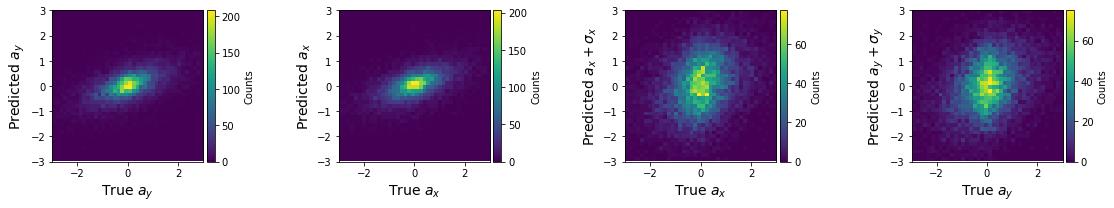

In [23]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

dataset = dataset_MS_1
train_data, val_data, test_data, all_data = split_dataset(dataset, train_frac=train_frac, val_frac=val_frac, randomize=False)
evaluation = evaluate_model(model_MS_2, val_data, verbose=False)

predictions = evaluation['predictions']
targets = evaluation['targets']
Overall_noise = estimate_noise_magnitude(model_MS_1, val_data)
print(Overall_noise)

predictions_fake = np.zeros(predictions.shape)
for i in range(len(predictions)):
    predictions_fake[i, 1] = predictions[i, 1] + np.random.normal(0, Overall_noise['per_dim_std'][1])
    predictions_fake[i, 0] = predictions[i, 0] + np.random.normal(0, Overall_noise['per_dim_std'][0])

fig, ax = plt.subplots(1, 4, figsize=(16, 3))

plot_configs = [
    (targets[:, 1], predictions[:, 1],      r'True $a_y$',            r'Predicted $a_y$'),
    (targets[:, 0], predictions[:, 0],      r'True $a_x$',            r'Predicted $a_x$'),
    (targets[:, 0], predictions_fake[:, 0], r'True $a_x$',            r'Predicted $a_x + \sigma_x$'),
    (targets[:, 1], predictions_fake[:, 1], r'True $a_y$',            r'Predicted $a_y + \sigma_y$'),
]

vmin, vmax = -3, 3

for a, (x, y, xlabel, ylabel) in zip(ax, plot_configs):
    heatmap, xedges, yedges = np.histogram2d(
        x, y, bins=40, range=[[vmin, vmax], [vmin, vmax]]
    )
    im = a.imshow(
        heatmap.T,
        extent=[vmin, vmax, vmin, vmax],
        origin='lower',
        cmap='viridis',
        aspect='equal'
    )
    a.set_xlabel(xlabel, fontsize=14)
    a.set_ylabel(ylabel, fontsize=14)

    # Colorbar matched to axes height
    divider = make_axes_locatable(a)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax, label='Counts')
#ax[0].plot(targets[:, 0],targets[:, 0],color = 'grey')
fig.tight_layout()
fig.savefig('Plots/ColorBarErrors_Mese.png',dpi=800)


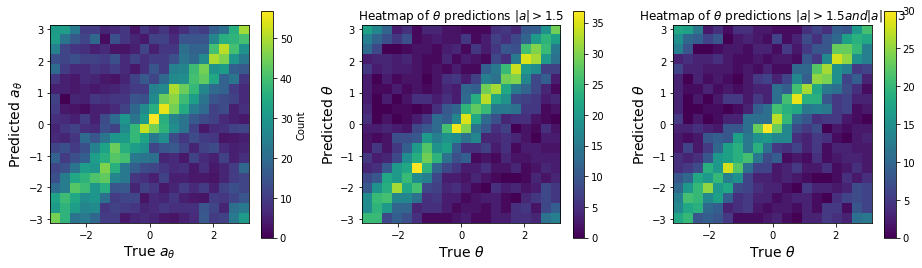

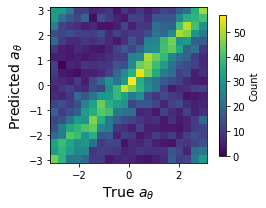

In [51]:
#predicted direction \theta vs true direction \theta

fig,ax = plt.subplots(1,3,figsize = (13,4))

theta_pred = np.arctan2(predictions[:, 1],predictions[:, 0])
theta_true = np.arctan2(targets[:, 1],targets[:, 0])
theta_pred_upper = np.arctan2(predictions[:, 1]+Overall_noise['per_dim_std'][1],predictions[:, 0]-Overall_noise['per_dim_std'][0])
theta_pred_lower = np.arctan2(predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 0]+Overall_noise['per_dim_std'][0])
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
#mask out thetas from accelerations < 0.5
amin = 1.0
valid_1 = a_mag > amin
amax = 2.5
valid_2 = a_mag < amax
valid = valid_1 & valid_2

theta_true_valid = theta_true[valid_1]
theta_pred_valid = theta_pred[valid_1]
theta_pred_upper_valid = theta_pred_upper[valid_1]
theta_pred_lower_valid = theta_pred_lower[valid_1]

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[1].set_xlabel(r'True $\theta$',fontsize = 14)
ax[1].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[1].set_title(r'Heatmap of $\theta$ predictions $|a|>1.5$')
cbar = fig.colorbar(ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[1], shrink=0.9)

theta_true_valid = theta_true[valid]
theta_pred_valid = theta_pred[valid]
theta_pred_upper_valid = theta_pred_upper[valid]
theta_pred_lower_valid = theta_pred_lower[valid]

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[2].set_xlabel(r'True $\theta$',fontsize = 14)
ax[2].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[2].set_title(r'Heatmap of $\theta$ predictions $|a|>1.5 and |a|<3$')
cbar = fig.colorbar(ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[2], shrink=0.9)

heatmap, xedges, yedges = np.histogram2d(theta_true, theta_pred, bins=20)
ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[0].set_xlabel(r'True $a_\theta$',fontsize = 14)
ax[0].set_ylabel(r'Predicted $a_\theta$',fontsize = 14)
#ax[0].set_title(r'Heatmap of $\theta$ predictions')
cbar = fig.colorbar(ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[0], shrink=0.9,label = "Count")

#make all colourbars the same


fig.tight_layout()

fig,ax = plt.subplots(1,figsize = (4,3))
ax.imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax.set_xlabel(r'True $a_\theta$',fontsize = 14)
ax.set_ylabel(r'Predicted $a_\theta$',fontsize = 14)
#ax[0].set_title(r'Heatmap of $\theta$ predictions')
cbar = fig.colorbar(ax.imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax, shrink=0.9,label = "Count")
fig.tight_layout()
fig.savefig("theta_pred_vs_true.png",dpi = 600)



In [54]:
ax = predictions[:, 0]
ay = predictions[:, 1]
ax_valid = ax[valid]
ay_valid = ay[valid]
sx = Overall_noise['per_dim_std'][0]
sy = Overall_noise['per_dim_std'][1]

sigma_a = np.sqrt(sx**2 + sy**2)

a_mag = np.sqrt(ax_valid**2 + ay_valid**2)

c = 5.0  # try 3, 5, 10
#valid = a_mag > c * sigma_a

den = ax_valid**2 + ay_valid**2
var_theta = (ay_valid**2 * sx**2 + ax_valid**2 * sy**2) / (den**2)

sigma_theta_global = np.sqrt(np.mean(var_theta))

print("kept fraction:", np.mean(valid))
print("Global sigma_theta (rad):", sigma_theta_global)
print("Global sigma_theta (deg):", np.degrees(sigma_theta_global))

dtheta = (theta_true_valid - theta_pred_valid + np.pi) % (2*np.pi) - np.pi  # wrap to [-pi,pi]
print(dtheta)
overall_theta_rms = np.sqrt(np.mean(dtheta*dtheta))
print("overall_theta_rms",overall_theta_rms)

targets_valid = targets #[valid]
ax = targets_valid[:,0]   # or predictions[:,0]
ay = targets_valid[:,1]   # or predictions[:,1]

sigma_x = Overall_noise['per_dim_std'][0]
sigma_y = Overall_noise['per_dim_std'][1]

den = ax**2 + ay**2
m = np.sqrt(den)

# mask out tiny magnitudes where direction is meaningless
m_min = 0 #5.0 * np.sqrt(sigma_x**2 + sigma_y**2)   # simple SNR threshold
valid = m > m_min

theta = np.arctan2(ay, ax)

var_theta = (ay**2 * sigma_x**2 + ax**2 * sigma_y**2) / (den**2)
sigma_theta = np.sqrt(var_theta)

print(np.mean(sigma_theta))

kept fraction: 0.000149947518368571
Global sigma_theta (rad): 0.62012744
Global sigma_theta (deg): 35.53068
[-0.41826916  0.8193555  -0.17591381 ... -1.5043056   1.4874299
  0.40050888]
overall_theta_rms 1.1315472
3580.01


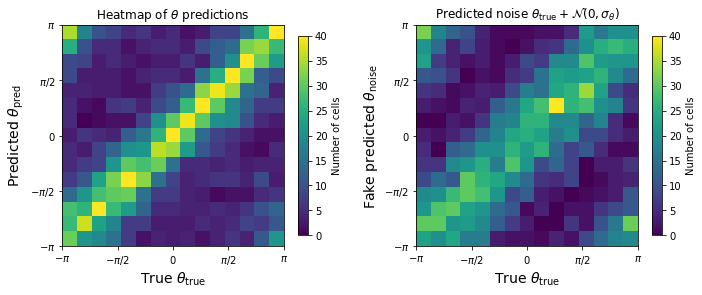

In [55]:
fig2,ax2 = plt.subplots(1,2,figsize = (10,4))

# calculate angular noise

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
#make some fake theta_pred from theta_true + gaussian noise. Noise taken from our estimate of the noise
theta_pred_fake = np.zeros(len(theta_true_valid))
for i in range(len(theta_true_valid)):
    theta_pred_fake[i] = theta_true_valid[i] + np.random.normal(0,overall_theta_rms) #theta_true[i] + 
    if theta_pred_fake[i] > np.pi:
        theta_pred_fake[i] = theta_pred_fake[i] - 2*np.pi
    elif theta_pred_fake[i] < -np.pi:
        theta_pred_fake[i] = theta_pred_fake[i] + 2*np.pi
heatmap_fake, xedges_fake, yedges_fake = np.histogram2d(theta_true_valid, theta_pred_fake, bins=20)
# 1) Use the SAME bin edges for both plots (critical)
bins = 15
# xmin, xmax = np.min(theta_true), np.max(theta_true)
# print(xmin, xmax)

# ymin = min(np.min(theta_pred), np.min(theta_pred_fake))
# ymax = max(np.max(theta_pred), np.max(theta_pred_fake))
# print(ymin, ymax)

xedges = np.linspace(-np.pi, np.pi, bins + 1)
yedges = np.linspace(-np.pi, np.pi, bins + 1)

heatmap, _, _      = np.histogram2d(theta_true_valid, theta_pred_valid,      bins=[xedges, yedges])
heatmap_fake, _, _ = np.histogram2d(theta_true_valid, theta_pred_fake, bins=[xedges, yedges])
heat_min = np.min(heatmap_fake)
heat_max = np.max(heatmap_fake)
# 2) Plot with identical extent + identical aspect
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im0 = ax2[0].imshow(heatmap.T, extent=extent, origin="lower",
                    cmap="viridis", aspect="equal",vmin = heat_min,vmax = heat_max)
im1 = ax2[1].imshow(heatmap_fake.T, extent=extent, origin="lower",
                    cmap="viridis", aspect="equal",vmin = heat_min,vmax = heat_max)

# 3) Force identical axis limits (belt + braces)
for ax in ax2:
    ax.set_xlim(xedges[0], xedges[-1])
    ax.set_ylim(yedges[0], yedges[-1])

# 4) One colorbar for both axes so layout stays aligned
cbar = fig2.colorbar(im0, ax=ax2[0], shrink=0.9)
cbar.set_label("Number of cells")
cbar = fig2.colorbar(im1, ax=ax2[1], shrink=0.9)
cbar.set_label("Number of cells")

# Labels/titles
ax2[0].set_xlabel(r"True $\theta_{\mathrm{{true}}}$", fontsize=14)
ax2[0].set_ylabel(r"Predicted $\theta_{\mathrm{{pred}}}$", fontsize=14)
ax2[0].set_title(r"Heatmap of $\theta$ predictions")

ax2[1].set_xlabel(r"True $\theta_{\mathrm{{true}}}$", fontsize=14)
ax2[1].set_ylabel(r"Fake predicted $\theta_{\mathrm{{noise}}}$", fontsize=14)
ax2[1].set_title(r"Predicted noise $\theta_{\mathrm{{true}}}+\mathcal{N}(0,\sigma_{\theta})$")
ax2[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])

fig2.tight_layout()

Fetching 1 example of a poor prediction

5787 1807


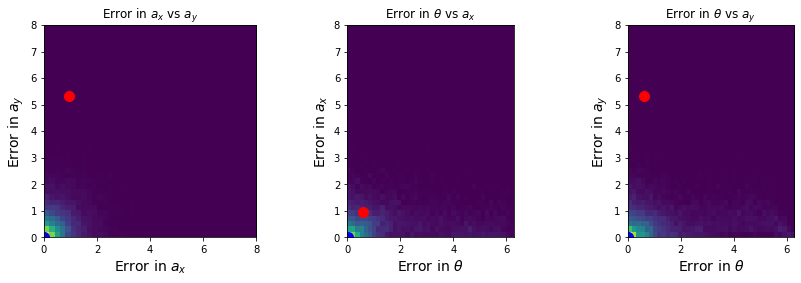

In [26]:
#make a list of error in a_x, a_y, theta
error_a_x = np.abs(predictions[:, 0] - targets[:, 0])
error_a_y = np.abs(predictions[:, 1] - targets[:, 1])
error_theta = np.abs(theta_pred - theta_true)
#make a histogram of error_a_x, error_a_y, error_theta

#choose a point which has high error in a_x, a_y, theta
error_a_x_norm = error_a_x / np.mean(error_a_x)
error_a_y_norm = error_a_y / np.mean(error_a_y)
error_theta_norm = error_theta / np.mean(error_theta)
Overall_error = np.sqrt(error_a_x_norm**2 + error_a_y_norm**2+error_theta_norm**2)
idx_max = np.argmax(Overall_error)
idx_min = np.argmin(Overall_error)
max_err = 8
fig,ax = plt.subplots(1,3,figsize = (12,4))
heatmap, xedges, yedges = np.histogram2d(error_a_x,error_a_y,bins=40,range=[[0, max_err], [0, max_err]])
ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[0].set_xlabel(r'Error in $a_x$',fontsize = 14)
ax[0].set_ylabel(r'Error in $a_y$',fontsize = 14)
ax[0].set_title(r'Error in $a_x$ vs $a_y$')

heatmap, xedges, yedges = np.histogram2d(error_theta,error_a_x,bins=40,range=[[0, 2*np.pi], [0, max_err]])
ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[1].set_xlabel(r'Error in $\theta$',fontsize = 14)
ax[1].set_ylabel(r'Error in $a_x$',fontsize = 14)
ax[1].set_title(r'Error in $\theta$ vs $a_x$')

heatmap, xedges, yedges = np.histogram2d(error_theta,error_a_y,bins=40,range=[[0, 2*np.pi], [0, max_err]])
ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[2].set_xlabel(r'Error in $\theta$',fontsize = 14)
ax[2].set_ylabel(r'Error in $a_y$',fontsize = 14)
ax[2].set_title(r'Error in $\theta$ vs $a_y$')





ax[0].plot(error_a_x[idx_max],error_a_y[idx_max],'o',color = 'red',markersize = 10)
ax[0].plot(error_a_x[idx_min],error_a_y[idx_min],'o',color = 'blue',markersize = 10)
ax[1].plot(error_theta[idx_max],error_a_x[idx_max],'o',color = 'red',markersize = 10)
ax[1].plot(error_theta[idx_min],error_a_x[idx_min],'o',color = 'blue',markersize = 10)
ax[2].plot(error_theta[idx_max],error_a_y[idx_max],'o',color = 'red',markersize = 10)
ax[2].plot(error_theta[idx_min],error_a_y[idx_min],'o',color = 'blue',markersize = 10)
print(idx_max,idx_min)
fig.tight_layout()



In [27]:
df_og_with_error = evaluate_model_frames(loaded_model,all_data,verbose = False)

Index(['frame', 'node_id', 'x', 'y', 'vx', 'vy', 'num_neighbors', 'nn_r',
       'error', 'error_theta', 'error_x', 'error_y', 'pred_x', 'pred_y',
       'target_x', 'target_y'],
      dtype='object')
138


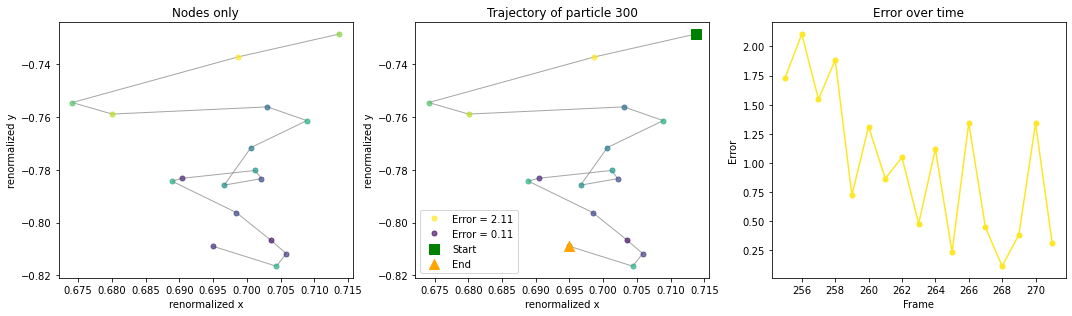

In [49]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
print(df_og_with_error.columns)
# Get first frame from train_data
frame_data = df_og_with_error[df_og_with_error['frame'] == 137]  # Fixed: get first element of list
print(len(df_og_with_error['frame'].unique()))
# Plot edges on second subplot


for i in range(1):
    ax[i].scatter(frame_data['x'], frame_data['y'], 
                  color='black', s=7)
    ax[i].scatter(frame_data['x'], frame_data['y'], 
                  color='black',alpha = 0.2, s=50)
    ax[i].set_xlabel(r'x [$\mu$ m]')
    ax[i].set_ylabel(r'y [$\mu$ m]')

#plot one node over time 
particle_id = 310
x_positions = []
y_positions = []

# Loop through all frames to find this particle
#sort data by frame
allNoShuffleOUT = sorted(all_data, key=lambda x: x['frame'])


# Plot one node over time using the DataFrame
particle_ids = [6]
cmap = plt.cm.viridis
# Filter the DataFrame for this particle_id and sort by frame
count = 0
error_type = 'error'
for particle_id in particle_ids:
    count+=1
    err_time_arr = []
    frames_arr = []
    particle_data = df_og_with_error[df_og_with_error['node_id'] == particle_id].sort_values('frame')
    if len(particle_data) > 0:
    # Plot using predicted positions (or use 'target_x', 'target_y' for true positions)
        ax[1].plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax[0].plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', linewidth=1, alpha=0.7)
        max_err = particle_data[error_type].max()
        min_err = particle_data[error_type].min()
        for xx in range(len(particle_data)):
            if particle_data[error_type].iloc[xx]==max_err or particle_data[error_type].iloc[xx]==min_err:
                ax[1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7,label = "Error = "+str(np.round(particle_data[error_type].iloc[xx],2)))
            
            else:
                ax[1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
            ax[0].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
            err_time_arr.append(particle_data[error_type].iloc[xx])
            frames_arr.append(particle_data['frame'].iloc[xx])
        ax[2].plot(frames_arr,err_time_arr,'o',color = cmap(count/len(particle_ids)),markersize = 5,linestyle ='-')
        
        # Optional: Also plot true positions
        # ax[1].plot(particle_data['target_x'], particle_data['target_y'], 's-', 
        #            color='blue', markersize=3, linewidth=1, alpha=0.5, label='True')
        
        # Mark start and end
        ax[1].scatter(particle_data['x'].iloc[0], particle_data['y'].iloc[0], 
                    color='green', s=100, marker='s', label='Start', zorder=5)
        ax[1].scatter(particle_data['x'].iloc[-1], particle_data['y'].iloc[-1], 
                    color='orange', s=100, marker='^', label='End', zorder=5)
        ax[1].legend()
    else:
        print(f"Particle {particle_id} not found in DataFrame")

ax[0].set_title('Nodes only')
ax[1].set_title('Trajectory of particle 300')
ax[2].set_title('Error over time')
ax[1].set_xlabel("renormalized x")
ax[1].set_ylabel("renormalized y")
ax[0].set_xlabel("renormalized x")
ax[0].set_ylabel("renormalized y")
ax[2].set_xlabel("Frame")
ax[2].set_ylabel(r"Error")

fig.tight_layout()

Particle 300 not found in DataFrame


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Particle 60 not found in DataFrame


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Particle 432 not found in DataFrame


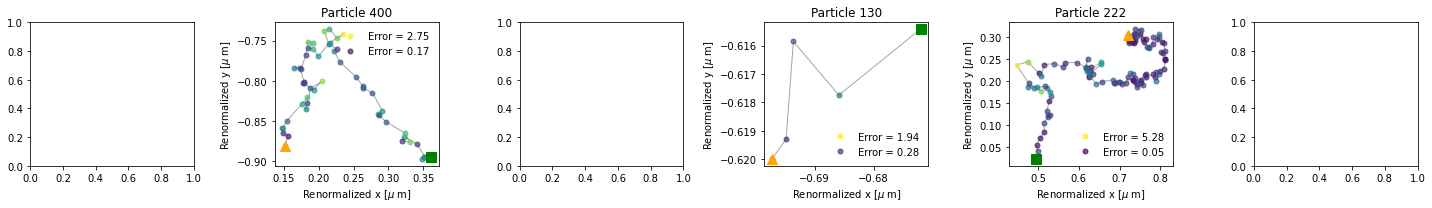

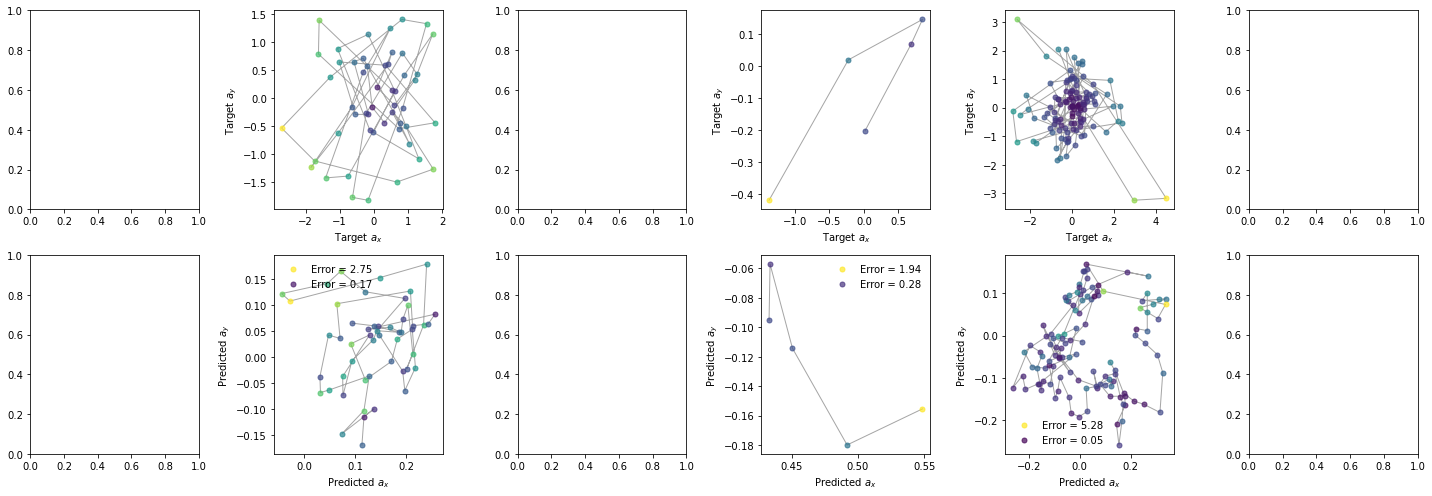

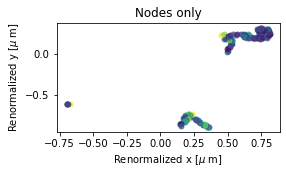

In [203]:
fig, ax = plt.subplots(1, 6, figsize=(20, 3))
fig2, ax2 = plt.subplots(2, 6, figsize=(20, 7))
particle_ids = [300,400,60,130,222,432]
fig0,ax0 = plt.subplots(1,1,figsize = (4,2))
count = 0
for particle_id in particle_ids:
    count+=1
    err_time_arr = []
    frames_arr = []
    particle_data = df_og_with_error[df_og_with_error['node_id'] == particle_id].sort_values('frame')
    if len(particle_data) > 0:
    # Plot using predicted positions (or use 'target_x', 'target_y' for true positions)
        ax[count-1].plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax2[0,count-1].plot(particle_data['target_x'], particle_data['target_y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax2[1,count-1].plot(particle_data['pred_x'], particle_data['pred_y'], '-', 
                color='grey', markersize=5, linewidth=1, alpha=0.7)
        ax0.plot(particle_data['x'], particle_data['y'], '-', 
                color='grey', linewidth=1, alpha=0.7)
        max_err = particle_data[error_type].max()
        min_err = particle_data[error_type].min()
        for xx in range(len(particle_data)):
            if particle_data[error_type].iloc[xx]==max_err or particle_data[error_type].iloc[xx]==min_err:
                ax[count-1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7,label = "Error = "+str(np.round(particle_data[error_type].iloc[xx],2)))
                ax2[0,count-1].plot(particle_data['target_x'].iloc[xx], particle_data['target_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                ax2[1,count-1].plot(particle_data['pred_x'].iloc[xx], particle_data['pred_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7,label = "Error = "+str(np.round(particle_data[error_type].iloc[xx],2)))
            
            else:
                ax[count-1].plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                ax2[0,count-1].plot(particle_data['target_x'].iloc[xx], particle_data['target_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                ax2[1,count-1].plot(particle_data['pred_x'].iloc[xx], particle_data['pred_y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
            ax0.plot(particle_data['x'].iloc[xx], particle_data['y'].iloc[xx], 'o', 
                    color=cmap(particle_data[error_type].iloc[xx]/max_err), markersize=5, linewidth=1, alpha=0.7)
                    
            err_time_arr.append(particle_data[error_type].iloc[xx])
            frames_arr.append(particle_data['frame'].iloc[xx])
        #ax[2].plot(frames_arr,err_time_arr,'o',color = cmap(count/len(particle_ids)),markersize = 5,linestyle ='-')
        
        # Optional: Also plot true positions
        # ax[1].plot(particle_data['target_x'], particle_data['target_y'], 's-', 
        #            color='blue', markersize=3, linewidth=1, alpha=0.5, label='True')
        
        # Mark start and end
        if count==1:
            ax[count-1].scatter(particle_data['x'].iloc[0], particle_data['y'].iloc[0], 
                        color='green', s=100, marker='s',label = 'Start', zorder=5)
            ax[count-1].scatter(particle_data['x'].iloc[-1], particle_data['y'].iloc[-1], 
                        color='orange', s=100, marker='^',label = 'End', zorder=5)
        else:
            ax[count-1].scatter(particle_data['x'].iloc[0], particle_data['y'].iloc[0], 
                        color='green', s=100, marker='s', zorder=5)
            ax[count-1].scatter(particle_data['x'].iloc[-1], particle_data['y'].iloc[-1], 
                        color='orange', s=100, marker='^', zorder=5)
        ax[count-1].legend(frameon=False)
        ax[count-1].set_xlabel("Renormalized x [$\mu$ m]")
        ax[count-1].set_ylabel("Renormalized y [$\mu$ m]")
        ax[count-1].set_title(f"Particle {particle_id}")
        ax2[0,count-1].legend(frameon=False)
        ax2[1,count-1].legend(frameon=False)
        ax2[0,count-1].set_xlabel(r"Target $a_{x}$")
        ax2[0,count-1].set_ylabel("Target $a_{y}$")
        ax2[1,count-1].set_xlabel("Predicted $a_{x}$")
        ax2[1,count-1].set_ylabel("Predicted $a_{y}$")
    else:
        print(f"Particle {particle_id} not found in DataFrame")

ax0.set_title('Nodes only')
ax0.set_xlabel("Renormalized x [$\mu$ m]")
ax0.set_ylabel("Renormalized y [$\mu$ m]")

fig.tight_layout()
fig2.tight_layout()

NumCells 1469
min frames 82
Pearson correlation: -0.024943461802283132
min num_frames_arr 1
max num_frames_arr 183
min av_err_time_arr 1.710592447234125
max av_err_time_arr 2.338471405208111
Pearson correlation: -0.04682030852888479
x_range > y_range
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 3

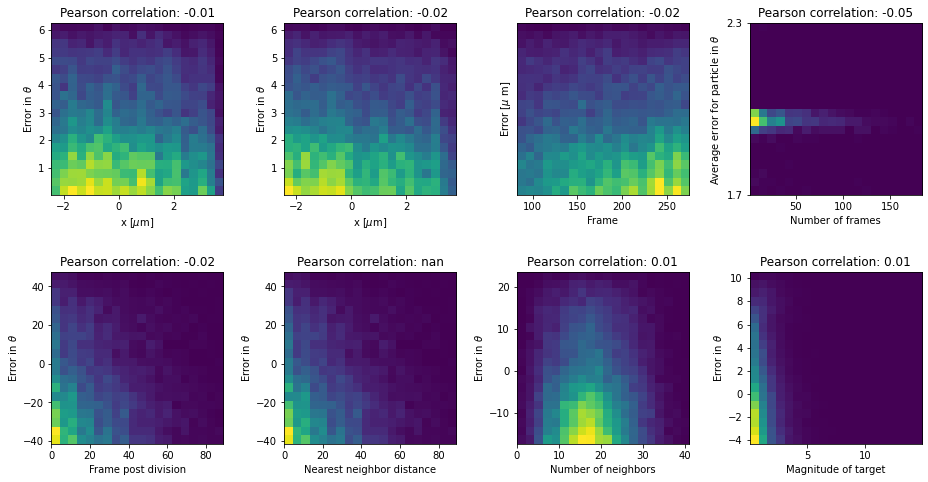

In [205]:
#Choose 30 random cells
#make arrays of x,y,error_a_x,error_a_y,error_theta,number of frames,frame number,local density,lifetime,n_neighbors_1hop
NumCells = len(df_og_with_error['node_id'].unique())
Ncells = NumCells #4000
print("NumCells",NumCells)
fig,ax = plt.subplots(2,4,figsize = (13,7))
err_time_arr = []
err_time_post_Div = []
frame_post_Div = []
frames_arr = []
x_pos_arr = []
y_pos_arr = []
av_err_time_arr = []
num_frames_arr = []
nn_r_arr = []
num_neighbors_arr = []
mag_target_arr = [] 
Nbins=20
counter = 0
error_type = 'error_theta'
for ii in range(Ncells):
    
    
    #choose a random cell
    # go through cells in order
    cell_idx = ii
    cell_data = df_og_with_error[df_og_with_error['node_id'] == cell_idx].sort_values('frame')
    if len(cell_data) > 0:
        for xx in range(len(cell_data)):
            err_time_arr.append(cell_data[error_type].iloc[xx])
            frames_arr.append(cell_data['frame'].iloc[xx])
            x_pos_arr.append(np.abs(cell_data['x'].iloc[xx]))
            y_pos_arr.append(np.abs(cell_data['y'].iloc[xx]))
            nn_r_arr.append(cell_data['nn_r'].iloc[xx])
            num_neighbors_arr.append(cell_data['num_neighbors'].iloc[xx])
            target_x = cell_data['target_x'].iloc[xx]
            target_y = cell_data['target_x'].iloc[xx]
            mag_target = np.sqrt(target_x**2+target_y**2)
            mag_target_arr.append(mag_target)
            # run through n_neighbors_1hop
            
            if np.min(cell_data['frame'])>181:
                err_time_post_Div.append(cell_data[error_type].iloc[xx])
                frame_post_Div.append(cell_data['frame'].iloc[xx]-np.min(cell_data['frame']))

        av_err_time_arr.append(np.mean(err_time_arr))
        num_frames_arr.append(len(cell_data))



        #ax[ii].plot(frames_arr,err_time_arr,'o',color = 'grey',markersize = 5,linewidth = 1,alpha = 0.7)
        #ax[ii].set_xlabel("Frame")
    else:
        counter+=1
    #    print(f"Particle {cell_idx} not found in DataFrame")
    #ax[ii].set_ylabel("Error in $\theta$")
    #ax[ii].set_title(f"Particle {cell_idx}")
heatmap, xedges, yedges = np.histogram2d(x_pos_arr,err_time_arr,bins=Nbins,range=[[np.min(x_pos_arr) ,np.max(x_pos_arr)], [np.min(err_time_arr), np.max(err_time_arr)]])
corr_pearson = np.corrcoef(x_pos_arr,err_time_arr)[0,1]
x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    x_min_plot = x_min
    x_max_plot = x_max

im = ax[0,0].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min, y_max],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[0,0].set_xlabel(r"x [$\mu$m]")
ax[0,0].set_ylabel(r"Error in $\theta$")
ax[0,0].set_title(f"Pearson correlation: {corr_pearson:.2f}")

heatmap, xedges, yedges = np.histogram2d(y_pos_arr,err_time_arr,bins=Nbins,range=[[np.min(y_pos_arr) ,np.max(y_pos_arr)], [np.min(err_time_arr), np.max(err_time_arr)]])
corr_pearson = np.corrcoef(y_pos_arr,err_time_arr)[0,1]
x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    x_min_plot = x_min
    x_max_plot = x_max

im = ax[0,1].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min, y_max],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[0,1].set_xlabel(r"x [$\mu$m]")
ax[0,1].set_ylabel(r"Error in $\theta$")
ax[0,1].set_title(f"Pearson correlation: {corr_pearson:.2f}")




heatmap, xedges, yedges = np.histogram2d(frames_arr,err_time_arr,bins=Nbins,range=[[np.min(frames_arr),np.max(frames_arr)], [np.min(err_time_arr), np.max(err_time_arr)]])
#correlation between num_frames_arr and av_err_time_arr
corr_pearson = np.corrcoef(frames_arr,err_time_arr)[0,1]
print("min frames",np.min(frames_arr))
#corr_spearman = np.corrcoef(num_frames_arr,av_err_time_arr,method='spearman')[0,1]
print(f"Pearson correlation: {corr_pearson}")
x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min #- pad
    x_max_plot = x_max #+ pad
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad


im = ax[0,2].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)

ax[0,2].set_xlabel("Frame")
ax[0,2].set_ylabel("Error [$\mu$ m]")
ax[0,2].set_yticks([])
ax[0,2].set_title(f"Pearson correlation: {corr_pearson:.2f}")


heatmap, xedges, yedges = np.histogram2d(num_frames_arr,av_err_time_arr,bins=Nbins,range=[[np.min(num_frames_arr),np.max(num_frames_arr)], [np.min(av_err_time_arr),np.max(av_err_time_arr)]])
print("min num_frames_arr",np.min(num_frames_arr))
print("max num_frames_arr",np.max(num_frames_arr))
print("min av_err_time_arr",np.min(av_err_time_arr))
print("max av_err_time_arr",np.max(av_err_time_arr))
#correlation between num_frames_arr and av_err_time_arr
corr_pearson = np.corrcoef(num_frames_arr,av_err_time_arr)[0,1]
#corr_spearman = np.corrcoef(num_frames_arr,av_err_time_arr,method='spearman')[0,1]
print(f"Pearson correlation: {corr_pearson}")

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad

im = ax[0,3].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[0,3].set_xlabel("Number of frames")
ax[0,3].set_ylabel(r"Average error for particle in $\theta$")
ax[0,3].set_yticks([y_min_plot,y_max_plot])
ax[0,3].set_yticklabels([np.round(np.min(av_err_time_arr),1),np.round(np.max(av_err_time_arr),1)])
ax[0,3].set_title(f"Pearson correlation: {corr_pearson:.2f}")

heatmap, xedges, yedges = np.histogram2d(frame_post_Div,err_time_post_Div,bins=Nbins,range=[[np.min(frame_post_Div),np.max(frame_post_Div)], [np.min(err_time_post_Div),np.max(err_time_post_Div)]])

corr_pearson = np.corrcoef(frame_post_Div,err_time_post_Div)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad


ax[1,0].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[1,0].set_xlabel("Frame post division")
ax[1,0].set_ylabel(r"Error in $\theta$")
ax[1,0].set_title(f"Pearson correlation: {corr_pearson:.2f}")


#heatmap, xedges, yedges = np.histogram2d(nn_r_arr,err_time_arr,bins=Nbins,range=[[np.min(nn_r_arr),np.max(nn_r_arr)], [np.min(err_time_arr),np.max(err_time_arr)]])
corr_pearson = np.corrcoef(nn_r_arr,err_time_arr)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
    y_min_plot = y_min
    y_max_plot = y_max
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad
    x_min_plot = x_min
    x_max_plot = x_max

ax[1,1].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[1,1].set_xlabel("Nearest neighbor distance")
ax[1,1].set_ylabel(r"Error in $\theta$")
ax[1,1].set_title(f"Pearson correlation: {corr_pearson:.2f}")

heatmap, xedges, yedges = np.histogram2d(num_neighbors_arr,err_time_arr,bins=Nbins,range=[[np.min(num_neighbors_arr),np.max(num_neighbors_arr)], [np.min(err_time_arr),np.max(err_time_arr)]])

corr_pearson = np.corrcoef(num_neighbors_arr,err_time_arr)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]
x_range = x_max - x_min
y_range = y_max - y_min
if x_range < y_range:
    print("x_range < y_range")
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
    y_min_plot = y_min
    y_max_plot = y_max
else:
    print("x_range > y_range")
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad
    x_min_plot = x_min
    x_max_plot = x_max

ax[1,2].imshow(
    heatmap.T,
    extent=[x_min, x_max, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)
ax[1,2].set_xlabel("Number of neighbors")
ax[1,2].set_ylabel(r"Error in $\theta$")
ax[1,2].set_title(f"Pearson correlation: {corr_pearson:.2f}")


heatmap, xedges, yedges = np.histogram2d(mag_target_arr,err_time_arr,bins=Nbins,range=[[np.min(mag_target_arr),np.max(mag_target_arr)], [np.min(err_time_arr),np.max(err_time_arr)]])
corr_pearson = np.corrcoef(mag_target_arr,err_time_arr)[0,1]

x_min, x_max = xedges[0], xedges[-1]
y_min, y_max = yedges[0], yedges[-1]

x_range = x_max - x_min
y_range = y_max - y_min

if x_range < y_range:
    pad = 0.5 * (y_range - x_range)
    x_min_plot = x_min - pad
    x_max_plot = x_max + pad
    y_min_plot = y_min
    y_max_plot = y_max
else:
    pad = 0.5 * (x_range - y_range)
    y_min_plot = y_min - pad
    y_max_plot = y_max + pad
    x_min_plot = x_min
    x_max_plot = x_max

ax[1,3].imshow(
    heatmap.T,
    extent=[x_min_plot, x_max_plot, y_min_plot, y_max_plot],
    origin='lower',
    cmap='viridis',
    aspect='equal'   # now means square bins
)

ax[1,3].set_xlabel("Magnitude of target")
ax[1,3].set_ylabel(r"Error in $\theta$")
ax[1,3].set_title(f"Pearson correlation: {corr_pearson:.2f}")

fig.tight_layout()



print(frame_post_Div)
    


Worst ax row: 26564 came from frame 102 node 134
Best ax row: 30810 came from frame 123 node 84


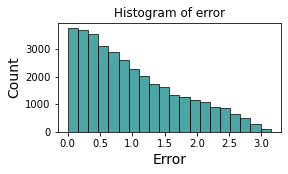

In [179]:
# get some more info on the point with high error in a_x, a_y, theta
# print(predictions[idx_max])
# print(targets[idx_max])
# print(theta_pred[idx_max])
# print(theta_true[idx_max])
# print(error_a_x[idx_max])
# print(error_a_y[idx_max])
# print(error_theta[idx_max])

# print(predictions[idx_min])
# print(targets[idx_min])
# print(theta_pred[idx_min])
# print(theta_true[idx_min])
# print(error_a_x[idx_min])
# print(error_a_y[idx_min])
# print(error_theta[idx_min])


Overall_error_norm = error_theta_norm #np.sqrt(error_a_x_norm**2 + error_a_y_norm**2 + error_theta_norm**2)
idx_max = np.argmax(Overall_error_norm)
idx_min = np.argmin(Overall_error_norm)

index_map   = evaluation['index_map']
frame_idx, node_idx = index_map[idx_max]
frame_idx_min, node_idx_min = index_map[idx_min]
print("Worst ax row:", idx_max, "came from frame", frame_idx, "node", node_idx)

print("Best ax row:", idx_min, "came from frame", frame_idx_min, "node", node_idx_min)
# histogram of Overall_error_norm
fig,ax = plt.subplots(1,1,figsize = (4,2))
ax.hist(Overall_error_norm,bins = 20,color = 'teal',edgecolor = 'black',alpha = 0.7)
ax.set_xlabel(r'Error',fontsize = 14)
ax.set_ylabel(r'Count',fontsize = 14)
ax.set_title(r'Histogram of error')
plt.show()

Worst ax row: 26564 came from frame 102 node 134
Best ax row: 30810 came from frame 123 node 84


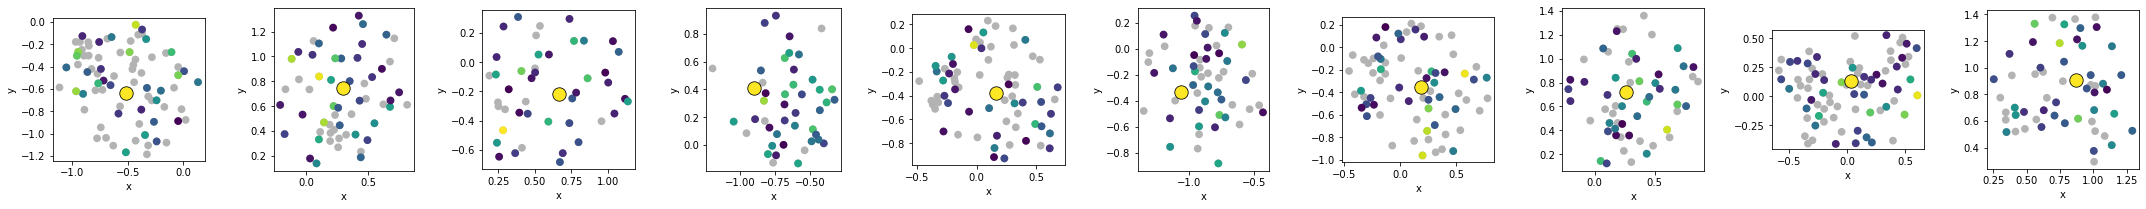

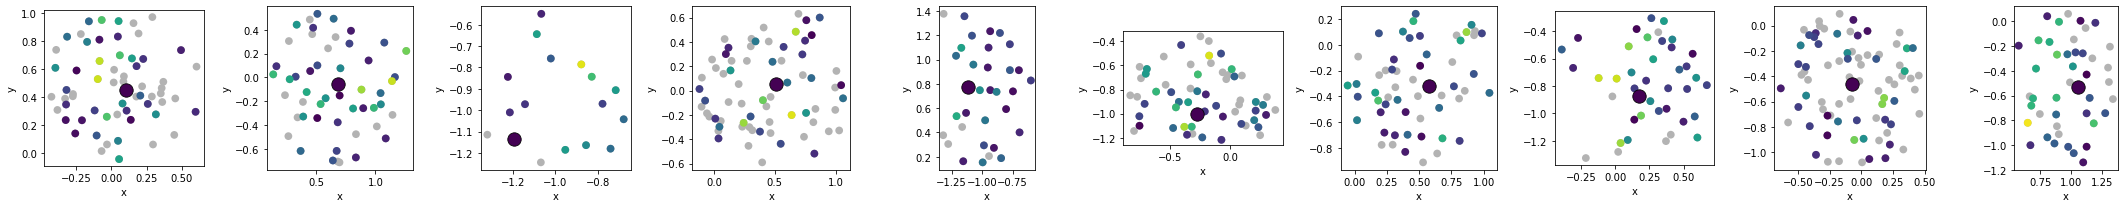

In [180]:
# Suppose you have per-node errors for this frame already:
# overall_err_frame is shape (num_nodes_in_frame,) with Overall_error_norm per node
# (or a dict; either is fine)

# Build dict of node->error for that frame from flattened arrays



index_map   = evaluation['index_map']

frame_idx_min, node_idx_min = index_map[idx_min]
print("Worst ax row:", idx_max, "came from frame", frame_idx, "node", node_idx)
print("Best ax row:", idx_min, "came from frame", frame_idx_min, "node", node_idx_min)

#get the IDs of the 10 worst nodes with maximum error
idx_worst = np.argsort(Overall_error_norm)[-10:]
fig,ax = plt.subplots(1,10,figsize = (30,3))
cc = 0
for ii in idx_worst:
    frame_idx, node_idx = index_map[ii]

    frame_idx_use = frame_idx
    neighbors_err_dict = {}
    for k, (f, n) in enumerate(index_map):
        if f == frame_idx_use:
            neighbors_err_dict[int(n)] = float(Overall_error_norm[k])

    err_center = neighbors_err_dict[node_idx]  # assuming you checked it's present/unmasked

    #err_center = float(overall_err_frame[node_idx])

    plot_2hop_center_only(
    train_data_[frame_idx],
    node_idx=node_idx,
    err_center=err_center,
    neighbors_err_dict=neighbors_err_dict,
    n_random_colored=40,
    show_colorbar=False,
    vmin=0,vmax=3,
    show_title=False,
    ax=ax[cc]
    )
    cc += 1
fig.tight_layout()


idx_best = np.argsort(Overall_error_norm)[:10]
fig,ax = plt.subplots(1,10,figsize = (30,3))
cc = 0
for ii in idx_best:
    frame_idx, node_idx = index_map[ii]

    frame_idx_use = frame_idx
    neighbors_err_dict = {}
    for k, (f, n) in enumerate(index_map):
        if f == frame_idx_use:
            neighbors_err_dict[int(n)] = float(Overall_error_norm[k])

    err_center = neighbors_err_dict[node_idx]  # assuming you checked it's present/unmasked

    #err_center = float(overall_err_frame[node_idx])

    plot_2hop_center_only(
    train_data_[frame_idx],
    node_idx=node_idx,
    err_center=err_center,
    neighbors_err_dict=neighbors_err_dict,
    n_random_colored=40,
    show_colorbar=False,
    vmin=0,vmax=3,
    show_title=False,
    ax=ax[cc]
    )
    cc += 1
fig.tight_layout()

In [76]:


err_center = Overall_error_norm[idx_max]     # <-- scalar error for the worst point
dp = train_data_[frame_idx]


#plot_2hop_center_only(dp, node_idx, err_center, show_colorbar=False)
plt.show()

frames_1509, err_1509 = node_error_over_frames(index_map, Overall_error_norm, node_id=1509)
print(np.argmin(np.abs(frames_1509-16)))
frame_id = np.argmin(np.abs(frames_1509-16))
print(err_1509[frame_id])

err_center = Overall_error_norm[idx_min]
dp = train_data_[frame_idx_min]
#plot_2hop_center_only(dp, node_idx_min, err_center, show_colorbar=False)
plt.show()

frames_2710, err_2710 = node_error_over_frames(index_map, Overall_error_norm, node_id=2710)
print(np.argmin(np.abs(frames_2710-7)))
frame_id = np.argmin(np.abs(frames_2710-7))
print(err_2710[frame_id])



NameError: name 'node_error_over_frames' is not defined

In [448]:
from collections import defaultdict

node_to_frames = defaultdict(list)

for k, (frame_idx, node_idx) in enumerate(index_map):
    node_to_frames[int(node_idx)].append(frame_idx)

# sort for safety
for n in node_to_frames:
    node_to_frames[n].sort()

In [449]:
rows = []

R_density = 0.1  # choose a physical length scale (important!)
total_nodes = len(index_map)
#choose subset of index_map
index_map_subset = index_map[:500] 
total_nodes_subset = len(index_map_subset)
for k, (frame_idx, node_idx) in enumerate(index_map_subset):
    #print progress every 5%
    if k % (total_nodes_subset//5) == 0:
        print(f"{k}/{total_nodes_subset}")

    dp = train_data_[frame_idx]
    nodes = dp["nodes"]
    edges = dp["edges"]

    xy = nodes[:, :2]
    N = len(xy)

    adj = build_adjacency(edges, N)

    # ---------- error ----------
    err = Overall_error_norm[k]

    # ---------- neighbors ----------
    n1 = adj[node_idx]
    n_neighbors_1hop = len(n1)

    n2 = set()
    for u in n1:
        n2 |= adj[u]
    n2 -= n1
    n2.discard(node_idx)
    n_neighbors_2hop = len(n2)

    # ---------- local density (metric) ----------
    deltas = xy - xy[node_idx]
    dists = np.linalg.norm(deltas, axis=1)
    local_density = np.sum((dists < R_density) & (dists > 0))

    # ---------- lifetime ----------
    frames = node_to_frames[node_idx]
    frames_present_total = len(frames)
    frames_since_birth = frame_idx - frames[0]

    #make sure frames has no NaNs
    

    rows.append({
        "error": err,
        "frame": frame_idx,
        "node": node_idx,
        "n_neighbors_1hop": n_neighbors_1hop,
        "n_neighbors_2hop": n_neighbors_2hop,
        "local_density": local_density,
        "frames_present_total": frames_present_total,
        "frames_since_birth": frames_since_birth,
    })


0/500


KeyboardInterrupt: 

In [179]:
import pandas
df_errorCorr = pandas.DataFrame(rows)

print(df_errorCorr[["frame","node","frames_present_total","frames_since_birth"]].head())
print(df_errorCorr[["frame","node","frames_present_total","frames_since_birth"]].dtypes)

print("NaNs per column:")
print(df_errorCorr[["frames_present_total","frames_since_birth"]].isna().sum())

   frame  node  frames_present_total  frames_since_birth
0      0     1                    28                   0
1      0     2                    28                   0
2      0     3                    25                   0
3      0     4                    28                   0
4      0     5                    30                   0
frame                   int64
node                    int64
frames_present_total    int64
frames_since_birth      int64
dtype: object
NaNs per column:
frames_present_total    0
frames_since_birth      0
dtype: int64


In [180]:

corr_pearson  = df_errorCorr.corr(method="pearson")["error"].sort_values(ascending=False)
corr_spearman = df_errorCorr.corr(method="spearman")["error"].sort_values(ascending=False)
df_errorCorr[["frame", "frames_since_birth"]].describe()
print("Pearson:\n", corr_pearson)
print("\nSpearman:\n", corr_spearman)

print(df_errorCorr["frames_since_birth"].std())
print(df_errorCorr["frame"].std())



Pearson:
 error                   1.000000
local_density           0.041833
n_neighbors_1hop        0.036362
node                    0.019528
frames_present_total    0.000202
n_neighbors_2hop       -0.017983
frame                        NaN
frames_since_birth           NaN
Name: error, dtype: float64

Spearman:
 error                   1.000000
n_neighbors_1hop        0.074387
local_density           0.067173
frames_present_total    0.020957
node                    0.014207
n_neighbors_2hop       -0.024540
frame                        NaN
frames_since_birth           NaN
Name: error, dtype: float64
0.0
0.0


In [156]:
# first frame in this dataset
frame_idx = 0
node_idx = 0

frame_idx = index_map[0][0]
print(frame_idx)


0


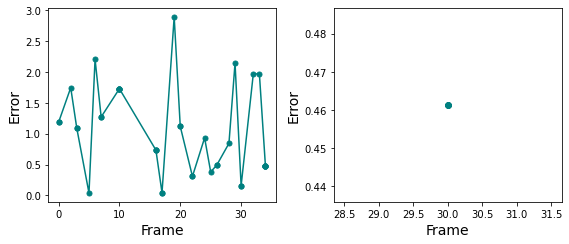

In [476]:
fig,ax = plt.subplots(1,2,figsize = (8,3.5))
# find the error in consecutive frames
errs_arr = []
frames_arr = []
for i in range(40):
    frame_id = np.argmin(np.abs(frames_1509-i))
    errs_arr.append(err_1509[frame_id])
    frames_arr.append(frames_1509[frame_id])
ax[0].plot(frames_arr,errs_arr,'o',color = 'teal',linestyle = '-',markersize = 5)
ax[0].set_xlabel('Frame',fontsize = 14)
ax[0].set_ylabel('Error',fontsize = 14)
#ax[0].set_title('Error in consecutive frames')

errs_arr = []
frames_arr = []
for i in range(40):
    frame_id = np.argmin(np.abs(frames_2710-i))
    errs_arr.append(err_2710[frame_id])
    frames_arr.append(frames_2710[frame_id])
ax[1].plot(frames_arr,errs_arr,'o',color = 'teal',linestyle = '-',markersize = 5)
ax[1].set_xlabel('Frame',fontsize = 14)
ax[1].set_ylabel('Error',fontsize = 14)
#ax[1].set_title('Error in consecutive frames')


fig.tight_layout()


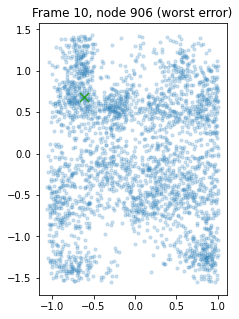

In [477]:
import numpy as np
import matplotlib.pyplot as plt

dp = train_data_[frame_idx]
nodes = dp['nodes']
edges = dp['edges']

xy = nodes[:, :2]
center = xy[node_idx]

# find neighbours via edges
mask_e = (edges[:,0] == node_idx) | (edges[:,1] == node_idx)
nbr_edges = edges[mask_e]
nbr_ids = np.unique(nbr_edges.flatten())
nbr_ids = nbr_ids[nbr_ids != node_idx]

fig, ax = plt.subplots(figsize=(5,5))

# plot all nodes faint
ax.scatter(xy[:,0], xy[:,1], s=10, alpha=0.2)

# plot neighbour nodes
ax.scatter(xy[nbr_ids,0], xy[nbr_ids,1], s=30)

# plot center node
ax.scatter(center[0], center[1], s=80, marker='x')

# draw edges connected to the node
for i, j in nbr_edges:
    ax.plot([xy[i,0], xy[j,0]], [xy[i,1], xy[j,1]], lw=1)

ax.set_aspect('equal', adjustable='box')
ax.set_title(f"Frame {frame_idx}, node {node_idx} (worst error)")
plt.show()


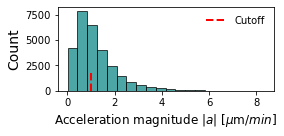

In [ ]:
atmap.png',dpi=1000)

[ 3.0751948  -1.660278   -0.30327338 ...  0.4507877  -2.832605
 -2.5839174 ]


array([-0.01552225,  0.05451025, -0.08500592, ..., -0.07292767,
        0.15864205,  0.04801881], dtype=float32)

kept fraction: 0.3996543380573799
Global sigma_theta (rad): 21.902847
Global sigma_theta (deg): 1254.9407


[-2.1821187  -1.9499093  -2.216501   ... -1.3592584   0.86979604
  1.614155  ]
overall_theta_rms 1.6987811


1.6736009


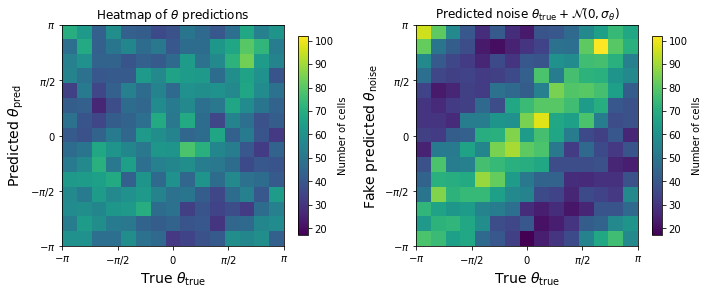

In [843]:
# name ="Version_i_UD_AllData"
# #name = "Version_i_OD_AllData_50_EMT"
# loaded_model = load_model(datasave+name+'.h5', 
#                          hidden_dim=64, 
#                          gamma_init=0.01, 
#                          save_format='weights')
# loaded_model_history = load_history(datasave+name+'_history.json')

# name2 ="Version_i_UD_PrevData_Attr_range70_49"
# name2 ="Version_i_UD_PrevData_Attr_range100_NoFenv_49"
name2 ="Version_iii_UD_AllData"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model7 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history7 = load_history(datasave+name+'_history.json')

# name2 ="Version_i_UD_AllData_50_Last50_EMT"
# #name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
# loaded_model3 = load_model(datasave+name2+'.h5', 
#                          hidden_dim=64, 
#                          gamma_init=0.01, 
#                          save_format='weights')
# loaded_model_history3 = load_history(datasave+name+'_history.json')


name ="Version_i_UD_AllData"
#name = "Version_i_OD_AllData_50_EMT"
loaded_model = load_model(datasave+name+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_PrevData_Attr_range70_49"
name2 ="Version_i_UD_PrevData_Attr_range100_NoFenv_49"
name2 ="Version_i_UD_AllData_50_First75_EMT"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model2 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history2 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_First50_EMT"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model3 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history3 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_First25_EMT"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model4 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history4 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_Last50_EMT"
loaded_model5 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history5 = load_history(datasave+name+'_history.json')

name2 ="Version_i_UD_AllData_50_Last25_EMT"
loaded_model6 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history6 = load_history(datasave+name+'_history.json')



# name = "Version_i_OD_AllData_50_EMT"
# loaded_model = load_model(datasave+name+'.h5', 
#                          hidden_dim=64, 
#                          save_format='weights')
# loaded_model_history = load_history(datasave+name+'_history.json')


# name2 = "Version_i_OD_Attr_range50_49"
# #name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
# loaded_model2 = load_model(datasave+name2+'.h5', 
#                          hidden_dim=64, 
#                          save_format='weights')
# loaded_model_history2 = load_history(datasave+name+'_history.json')



ForceGNN model created with hidden_dim=64, gamma_init=0.01
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData.h5
  hidden_dim=64, gamma_init=0.01
  Learned gamma value: -0.039420
Training history loaded from: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_history.json
  Number of epochs: 60
  Final train loss: 665.299622
  Final val loss: 658.258667
ForceGNN model created with hidden_dim=64, gamma_init=0.01
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_50_First75_EMT.h5
  hidden_dim=64, gamma_init=0.01
  Learned gamma value: -0.044646
Training history loaded from: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_history.json
  Number of epochs: 60
  Final train loss: 665.299622


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_50_Last75_EMT.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [844]:
name2 ="Version_iii_UD_AllData"
#name2 ="Version_i_UD_PrevData_Attr_range70_NoFenv_49"
loaded_model7 = load_model(datasave+name2+'.h5', 
                         hidden_dim=64, 
                         gamma_init=0.01, 
                         save_format='weights')
loaded_model_history7 = load_history(datasave+name+'_history.json')

ForceGNN model created with hidden_dim=64, gamma_init=0.01
Model loaded from weights: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_iii_UD_AllData.h5
  hidden_dim=64, gamma_init=0.01
  Learned gamma value: 0.026010
Training history loaded from: /Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/AmandaDataGNN/models/Version_i_UD_AllData_history.json
  Number of epochs: 60
  Final train loss: 665.299622
  Final val loss: 658.258667


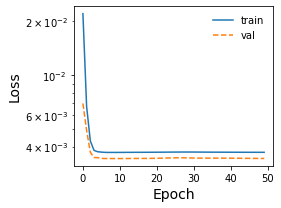

In [81]:
# Plot training history
fig,ax  = plt.subplots(figsize = (4,3))
#history2 = loaded_model_history

ax.plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train')
ax.plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val')
#ax.plot(history2['train_loss'],color = 'black',linestyle = ':',label = 'train')#
#ax.plot(history2['val_loss'],color = 'black',linestyle = ':',label = 'val')
ax.legend(frameon = False)
ax.set_yscale('log')
ax.set_xlabel('Epoch',fontsize = 14)
ax.set_ylabel('Loss',fontsize = 14)
fig.tight_layout()


In [82]:
# noise_stats = estimate_noise_magnitude(model, test_data)
# #print(f"Per-dimension std: {noise_stats['per_dim_std']}")
# print(f"Overall RMS: {noise_stats['overall_rms']}")
# print(f"Number of samples: {noise_stats['num_samples']}")
# print(f"Mean residual: {noise_stats['mean_residual']}")  # Should be ~0 if unbiased
#Gamma = -get_gamma(model)
Gamma2 = -get_gamma(model)
#Gamma3 = -get_gamma(loaded_model2)
#print(f"Gamma: {Gamma}")
print(f"Gamma2: {Gamma2}")
#print(f"Gamma3: {Gamma3}")
#print(f"Gamma2: {Gamma2}")
# #GammaTrue = 1/(damp*frame)
# #print(f"Real Noise: {MagnutudeNoise} should equal overall_rms {noise_stats['overall_rms']}")
# fig,ax=plt.subplots(1,2,figsize=(8,3))
# ax[0].plot([0,1],[noise_stats['overall_rms'],noise_stats['overall_rms']],color = clrs[0],marker = 'o',linestyle = '')
# ax[0].set_xticks([0,1])
# ax[0].set_xticklabels(['Real Noise','Model Noise'])
# ax[1].plot([0,1],[Gamma,Gamma],color = clrs[1],marker = 'o',linestyle = '')
# ax[1].set_xticks([0,1])
# ax[1].set_xticklabels(['True Gamma','Model Gamma'])
# ax[1].set_ylabel('Noise Magnitude')
# fig.tight_layout()

Gamma2: 0.03424461930990219


In [677]:
def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    return dEdr

def force_environment(x,y,kappa_x,kappa_y,x_0,y_0):
    r_vec = np.array([x-x_0,y-y_0])
    r = np.linalg.norm(r_vec)
    Fx = -kappa_x*(x-x_0)
    Fy = -kappa_y*(y-y_0)
    return np.array([Fx,Fy])
    

In [43]:
# Get force at a specific distance
sigma = 1.5
l_da = 0.1
rcut = sigma*2
epsilon = 0.5
r_arr = np.linspace(0.30,50/max_dist)
force_infer = []
force_infer2 = []
force_infer3 = []
force_infer4 = []
force_true = []
for r in r_arr:
    #force_infer.append(get_force_at_distance(loaded_model3, r))
    #force_infer2.append(get_force_at_distance(loaded_model, r))
    #force_infer3.append(get_force_at_distance(loaded_model2, r))
    force_infer4.append(get_force_at_distance(model, r))
    #force_true.append(soft_lj_force(r, epsilon, sigma, rcut, l_da))
    #print(f"Force at distance r={r}: {force:.6f}")


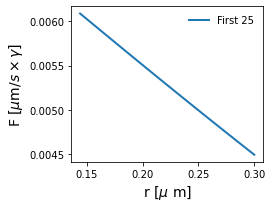

In [44]:

r_arr_plot = np.multiply(r_arr,max_dist)
fig,ax  = plt.subplots(figsize = (4,3))
scaleF = 1
ax.plot(r_arr,np.multiply(force_infer4,scaleF),color = clrs[0],linestyle = '-',linewidth = 2,label = 'First 25')
#
#ax.plot(r_arr,np.multiply(force_infer,scaleF),color = clrs[2],linestyle = '-',linewidth = 2,label = 'First 50')
#ax.plot(r_arr,np.multiply(force_infer3,scaleF),color = 'tab:pink',linestyle = '-',linewidth = 2,label = 'First 75')
#ax.plot(r_arr,np.multiply(force_infer2,scaleF),color = 'tab:purple',linestyle = '-',linewidth = 2,label = 'All data')

#ax.plot(r_arr,list(force_true),color = 'black',linestyle = ':',label = 'actual')
ax.set_xlabel(r'r [$\mu$ m]',fontsize = 14)
ax.set_ylabel(r'F [$\mu$m$/s \times \gamma$]',fontsize = 14)
#ax.set_ylim([-0.2,1.5])
#ax.plot([0,50],[0,0],'k--')
ax.legend(frameon = False)
#ax.set_ylim([-0.5,2.4])
fig.tight_layout()

# # Query multiple distances
# distances = [0.8, 1.0, 1.5, 2.0, 2.5, 3.0]
# for r in distances:
#     force = get_force_at_distance(model, r)
#     print(f"r={r:.1f}: F_r={force:.6f}")


In [ ]:
# Evaluate on test data
data_trains = train_data_rolling #[train_data_0,train_data_1,train_data_2,train_data_3,train_data_4,train_data_5]
r_squares = []
r_squares_ax = []
r_squares_ay = []
#for i in range(len(trains)):
evaluation = evaluate_model(loaded_model,train_data,verbose = False)
#print("Evaluating ",i,"out of ",len(data_trains))

# Plot predictions vs actual
#plot_predictions(evaluation)
predictions = evaluation['predictions']
targets = evaluation['targets']
# fig,ax = plt.subplots(1,2,figsize = (8,3))
# ax[0].plot(targets[:, 0],predictions[:, 0],'o',color = clrs[2],linestyle = '',markersize = 2)
# ax[0].plot(targets[:, 0],targets[:, 0],'r--',linewidth = 2)
# ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = clrs[2],linestyle = '',markersize = 2)
# ax[1].plot(targets[:, 1],targets[:, 1],'r--',linewidth = 2)
# ax[0].set_xlabel(r'Target $a_x$',fontsize = 14)
# ax[0].set_ylabel(r'Predicted $a_x$',fontsize = 14)
# ax[1].set_xlabel(r'Target $a_y$',fontsize = 14)
# ax[1].set_ylabel(r'Predicted $a_y$',fontsize = 14)
# ax[0].legend(frameon = False)
# fig.tight_layout()

# calculate R^2 (on test data)
# R^2 = 1 - (sum((y_true - y_pred)**2)) / (sum((y_true - y_mean)**2))
# R^2 = 1- evaluation['mse']/\sum(targets-np.mean(targets))**2
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)

print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")
#ax[0].set_ylim([-1,1])
r_squares.append((rsq_ax+rsq_ay)/2)
r_squares_ax.append(rsq_ax)
r_squares_ay.append(rsq_ay)


R^2 for ax: 0.0017
R^2 for ay: 0.0018
Average R^2: 0.0017


In [153]:
print(r_squares)
print(r_squares_ax)
print(r_squares_ay)
print("var ax:", np.var(targets[:,0]), "var ay:", np.var(targets[:,1]))
print("std ax:", np.std(targets[:,0]), "std ay:", np.std(targets[:,1]))


[0.0005799233913421631, -0.006135702133178711, -0.0064792633056640625, -0.005572915077209473, -7.787346839904785e-05, 0.0023116767406463623, 0.000951617956161499, 0.0002193450927734375, -1.9341707229614258e-05, 0.0005606412887573242, -0.0015418529510498047, -0.0001849532127380371, 0.001377195119857788, 0.0011031925678253174, 0.0006569921970367432, 0.0007000565528869629, 0.000549614429473877, 1.2189149856567383e-05, -0.0006220340728759766, -0.0010631084442138672, 0.0019764304161071777, 0.0024518072605133057, 0.003076612949371338, 0.002116560935974121, 0.0019738972187042236, -0.00029718875885009766, 0.0007128119468688965, 0.000457763671875, 0.0007289350032806396, 0.0008140504360198975, 0.0002789497375488281, -0.001381605863571167, 0.0009543895721435547, 0.00188446044921875, 0.0014324188232421875, 0.0012323558330535889, 0.0011709034442901611, 0.00014865398406982422, -0.000991910696029663, -0.0012792348861694336, -0.0018449127674102783, -0.0018864870071411133, -0.00587087869644165, -0.0012

In [46]:
# Plot force components for a test frame
kappa_x = 0.4
kappa_y = 0.2
#get x and y from the min and max of the data
x_min = data_clean['x'].min()
x_max = data_clean['x'].max()
y_min = data_clean['y'].min()
y_max = data_clean['y'].max()
print(x_min,x_max,y_min,y_max)
x_arr = np.linspace(x_min,x_max,40)
y_arr = np.linspace(y_min,y_max,40)
x_arr_real = np.linspace(x_min*max_dist*0.9,x_max*max_dist*0.9,40)
y_arr_real = np.linspace(y_min*max_dist*0.9,y_max*max_dist*0.9,40)
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
F_env_true = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = get_force_environment(model, x, y)
        #F_env_true[i,j,:] = force_environment(x,y,kappa_x,kappa_y,0,0)

# Plot force components for a test frame

-0.8547702727015694 0.82578656275203 -0.9 0.7766435018030129


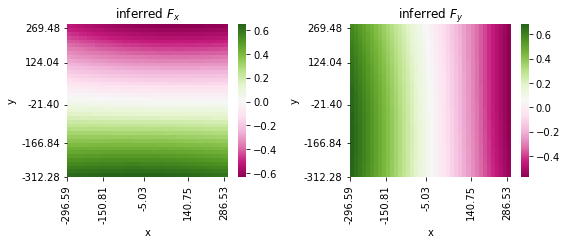

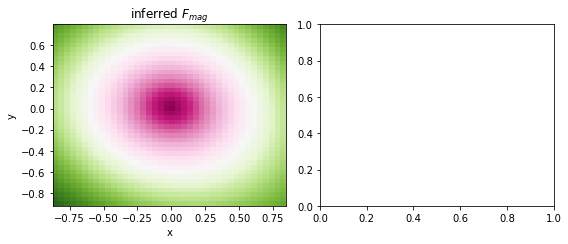

In [48]:
fig,ax = plt.subplots(1,2,figsize = (8,3.5))
fig2,ax2 = plt.subplots(1,2,figsize = (8,3.5))
x_ticks_plot = np.linspace(x_min*max_dist,x_max*max_dist,5)
y_ticks_plot = np.linspace(y_min*max_dist,y_max*max_dist,5)
x_tick_indices = [np.argmin(np.abs(x_arr_real - val)) for val in x_ticks_plot]
y_tick_indices = [np.argmin(np.abs(y_arr_real - val)) for val in y_ticks_plot]

# Create heatmaps
#vmin = -3
#vmax = 3
sns.heatmap(F_env_infer[:,:,0], ax=ax[0], cmap='PiYG',
            xticklabels=[f'{x:.2f}' for x in x_ticks_plot],
            yticklabels=[f'{y:.2f}' for y in y_ticks_plot])

sns.heatmap(F_env_infer[:,:,1], ax=ax[1], cmap='PiYG',
            xticklabels=[f'{x:.2f}' for x in x_ticks_plot],
            yticklabels=[f'{y:.2f}' for y in y_ticks_plot])

# Set tick positions
for i in range(2):
    ax[i].set_xticks(x_tick_indices)
    ax[i].set_xticklabels([f'{x:.2f}' for x in x_ticks_plot])
    ax[i].set_yticks(y_tick_indices)
    ax[i].set_yticklabels([f'{y:.2f}' for y in y_ticks_plot])


ax[0].invert_yaxis()
ax[1].invert_yaxis()
##ax[0].set_xticks(ax[0].get_xticks()[::4])
#ax[1].set_xticks(ax[1].get_xticks()[::4])
ax[0].set_title(r'inferred $F_x$')
ax[1].set_title(r'inferred $F_y$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.tight_layout()

# plot force magnitude
F_mag = np.linalg.norm(F_env_infer, axis=2)  # shape (len(x_arr), len(y_arr))

# Create coordinate grid (note indexing='ij' to match F_env_infer[i,j,:])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')
ax2[0].pcolormesh(X, Y, F_mag, shading='auto', cmap='PiYG')
ax2[0].set_title(r'inferred $F_{mag}$')
ax2[0].set_xlabel('x')
ax2[0].set_ylabel('y')
fig2.tight_layout()



# fig,ax = plt.subplots(1,2,figsize = (8,3))
# sns.heatmap(F_env_infer[:,:,1],ax=ax[0], cmap='viridis')
# sns.heatmap(F_env_true[:,:,1],ax=ax[1], cmap='viridis')
# ax[0].set_title(r'inferred $F_y$')
# ax[1].set_title(r'actual $F_y$')
# ax[0].set_xlabel('x')
# ax[0].set_ylabel('y')
# ax[1].set_xlabel('x')
# ax[1].set_ylabel('y')
# fig.tight_layout()


In [101]:

def node_error_over_frames(index_map, overall_error, node_id):
    """
    Returns two arrays (frames, errors) for all occurrences of node_id
    in the flattened masked arrays.
    """
    index_map_arr = np.asarray(index_map, dtype=int)  # shape (M, 2)
    frames = index_map_arr[:, 0]
    nodes  = index_map_arr[:, 1]

    sel = (nodes == int(node_id))
    frames_sel = frames[sel]
    errors_sel = np.asarray(overall_error)[sel]

    # sort by frame index (just in case)
    order = np.argsort(frames_sel)
    return frames_sel[order], errors_sel[order]


In [75]:
def get_edge_pairs(edges):
    edges = np.asarray(edges)
    if edges.ndim == 2 and edges.shape[0] == 2:      # (2, E)
        return edges.T.astype(int)
    if edges.ndim == 2 and edges.shape[1] >= 2:      # (E, 2+)
        return edges[:, :2].astype(int)
    raise ValueError(f"Unrecognized edges shape {edges.shape}")

def plot_2hop_center_only(
    data_point,
    node_idx,
    err_center,
    neighbors_err_dict=None,
    n_random_colored=0,
    hop=2,
    cmap="viridis",
    vmin=0.0,
    vmax=5.0,
    show_colorbar=True,
    ax=None,
    seed=None,
    neighbor_size=60,
    center_size=180,
    show_title=True,
):
    """
    Plot ONLY node_idx and its 1-hop and 2-hop neighbors on a given axis.

    - neighbors grey
    - center colored by err_center
    - randomly choose n_random_colored neighbors to color by error
    - fixed color scale [vmin, vmax]
    - no lines
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    else:
        fig = ax.figure

    nodes = data_point["nodes"]
    edges = data_point["edges"]
    xy = nodes[:, :2]
    N = xy.shape[0]
    node_idx = int(node_idx)

    # --- edges ---
    edge_pairs = get_edge_pairs(edges)

    # --- adjacency ---
    adj = [set() for _ in range(N)]
    for i, j in edge_pairs:
        i = int(i); j = int(j)
        adj[i].add(j)
        adj[j].add(i)

    # --- BFS to hop ---
    frontier = {node_idx}
    visited = {node_idx}
    layers = [set([node_idx])]

    for _ in range(hop):
        nxt = set()
        for u in frontier:
            nxt |= adj[u]
        nxt -= visited
        layers.append(nxt)
        visited |= nxt
        frontier = nxt

    first  = layers[1] if len(layers) > 1 else set()
    second = layers[2] if len(layers) > 2 else set()
    neighbor_nodes = sorted(list(first | second))

    # --- random neighbors to color ---
    rng = np.random.default_rng(seed)
    n_pick = min(int(n_random_colored), len(neighbor_nodes))
    picked = rng.choice(neighbor_nodes, size=n_pick, replace=False).tolist() if n_pick > 0 else []

    neighbors_err_dict = neighbors_err_dict or {}
    picked_with_err = [n for n in picked if n in neighbors_err_dict]

    # --- plot ---
    if neighbor_nodes:
        ax.scatter(
            xy[neighbor_nodes, 0], xy[neighbor_nodes, 1],
            s=neighbor_size, color="0.7", edgecolors="none"
        )

    if picked_with_err:
        vals = [neighbors_err_dict[n] for n in picked_with_err]
        ax.scatter(
            xy[picked_with_err, 0], xy[picked_with_err, 1],
            c=vals, s=neighbor_size,
            cmap=cmap, vmin=vmin, vmax=vmax,
            edgecolors="none"
        )

    sc_center = ax.scatter(
        [xy[node_idx, 0]], [xy[node_idx, 1]],
        c=[err_center], s=center_size,
        cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolors="k", linewidths=0.8
    )

    if show_colorbar:
        cbar = fig.colorbar(sc_center, ax=ax)
        cbar.set_label("Overall_error_norm")

    ax.set_aspect("equal", adjustable="box")
    if show_title:
        ax.set_title(
            f"node {node_idx} | err={err_center:.3g} | "
            f"colored {len(picked_with_err)}/{n_pick}"
        )
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # --- zoom ---
    local_nodes = [node_idx] + neighbor_nodes
    xs = xy[local_nodes, 0]
    ys = xy[local_nodes, 1]
    pad_x = 0.05 * (xs.max() - xs.min() + 1e-9)
    pad_y = 0.05 * (ys.max() - ys.min() + 1e-9)
    ax.set_xlim(xs.min() - pad_x, xs.max() + pad_x)
    ax.set_ylim(ys.min() - pad_y, ys.max() + pad_y)

    return ax


In [74]:
def build_adjacency(edges, N):
    edge_pairs = get_edge_pairs(edges)
    adj = [set() for _ in range(N)]
    for i, j in edge_pairs:
        adj[i].add(j)
        adj[j].add(i)
    return adj


